# Clasificación de Imágenes del Dataset ASL (Lenguaje de Señas Americano) mediante Aprendizaje Supervisado

Desarrolado e implementado por:
- Juan Francisco Gonzalez Pacheco - Cod: 2021114063
- Shania Maía Russo De Ávila      - Cod: 2021114030
- Isabel Duran Alvear             - Cod: 2022114033

Curso de Inteligencia Artificial, 2026-1
Phd. Ing. Idanis Beatriz Díaz Bolaño

El Lenguaje de Señas Americano (ASL) es el sistema de comunicación principal
de la comunidad sorda en Estados Unidos. Automatizar el reconocimiento de sus
señas mediante visión por computadora permite construir herramientas de
accesibilidad, traductores en tiempo real y sistemas educativos que reduzcan
la brecha de comunicación entre personas oyentes y no oyentes.

Este proyecto aborda el problema como una tarea de **clasificación**:
dada una imagen de una mano haciendo una seña, el modelo debe predecir a qué
letra del alfabeto (A–Z) corresponde.

**Fuente:** [American Sign Language Alphabet Dataset — Kaggle](https://www.kaggle.com/datasets/rupaul007/american-sign-language-alphabet-dataset)


Alternativamente, puedes descargar el dataset **aquí:** https://bit.ly/ASLjuan 




| Característica | Valor |
|---|---|
| Clases | 26 (letras A–Z) |
| Imágenes por clase | 200 |
| Total de imágenes | 5,200 |
| Formato original | JPG |

Cada imagen incluye anotaciones de 21 nodos de referencia de la mano, lo que la hace compatible con sistemas de seguimiento de manos como MediaPipe u OpenCV.

## Justificación

El reconocimiento automático de lenguaje de señas es un problema de visión 
por computadora con impacto directo en accesibilidad. Los modelos de 
aprendizaje supervisado permiten aprender patrones visuales directamente 
de los datos sin necesidad de programar reglas manualmente, lo que los hace 
adecuados para tareas donde la variabilidad visual entre clases es alta.

Este proyecto explora el pipeline completo: desde la inspección y 
preprocesamiento del dataset hasta el entrenamiento, ajuste de hiperparámetros 
y evaluación comparativa de modelos clásicos (Árbol de Decisión, Random Forest 
y MLP) y una red neuronal convolucional (CNN). El análisis incluye no solo las 
métricas sobre el dataset, sino también una evaluación cualitativa con imágenes 
reales externas que permite identificar las limitaciones de generalización de 
los modelos entrenados.


## Objetivo general
Entrenar y comparar modelos de aprendizaje supervisado para la clasificación de las 26 letras del alfabeto ASL a partir de imágenes de manos, evaluando su desempeño mediante métricas cuantitativas y analizando su capacidad de generalización a condiciones reales de uso.

## Objetivos específicos
- Inspeccionar y preprocesar el dataset de imágenes ASL para dejarlo en condiciones adecuadas para el entrenamiento.
- Reducir la dimensionalidad del dataset mediante PCA, conservando el 95% de la varianza explicada.
- Entrenar y ajustar hiperparámetros de cuatro modelos supervisados: Árbol de Decisión, Random Forest, MLP y CNN.
- Evaluar el desempeño de cada modelo sobre el conjunto de prueba usando accuracy, precision, recall y F1-score.
- Comparar los modelos entre sí e identificar las limitaciones de generalización a imágenes reales externas.
- Analizar las implicaciones éticas de una aplicación real del sistema desarrollado.

## Variable objetivo

La variable a predecir es la **letra del alfabeto ASL** representada en cada imagen. Es una variable categórica nominal con 26 categorías posibles (A–Z).

## LIBRERIAS

In [2]:
import os
import cv2
import json
import time
import pickle
import shutil
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

print("Librerías cargadas correctamente.")
print(f"  OpenCV      : {cv2.__version__}")
print(f"  NumPy       : {np.__version__}")
print(f"  Pandas      : {pd.__version__}")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  Keras       : {tf.keras.__version__}")

Librerías cargadas correctamente.
  OpenCV      : 4.13.0
  NumPy       : 2.4.5
  Pandas      : 3.0.3
  TensorFlow  : 2.21.0
  Keras       : 3.14.1


## RUTAS PARA EL NOTEBOOK

In [3]:
# Carpeta raíz: donde está el notebook
BASE = os.path.dirname(os.path.abspath("/Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/asl.ipynb"))

# Dataset original descargado de Kaggle
DATASET_RAW = "/Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/dataset/Dataset"

# Carpetas intermedias que se crearán automáticamente
DATASET_CROPPED  = os.path.join(BASE, "Dataset_cropped")
DATASET_RESIZED  = os.path.join(BASE, "Dataset_resized")
DATASET_GRAY     = os.path.join(BASE, "Dataset_gray")

# Archivos de salida
CSV_VECTORIZADO  = os.path.join(BASE, "asl_dataset.csv")
CSV_PCA_95       = os.path.join(BASE, "asl_pca_95.csv")
CSV_PCA_97       = os.path.join(BASE, "asl_pca_97.csv")
PKL_PCA_95       = os.path.join(BASE, "pca_model_95.pkl")
PKL_PCA_97       = os.path.join(BASE, "pca_model_97.pkl")

# Carpeta de salida para división del dataset
ENTRENA_DIR      = os.path.join(BASE, "Entrenamiento")

# ── Rutas CNN ────────────────────────────────────────────
CNN_DIR   = os.path.join(ENTRENA_DIR, "cnn")
TRAIN_DIR = os.path.join(CNN_DIR, "train")
VAL_DIR   = os.path.join(CNN_DIR, "val")
TEST_DIR  = os.path.join(CNN_DIR, "test")

# Verificar que el dataset original existe antes de continuar
assert os.path.isdir(DATASET_RAW), (
    f"No se encontró la carpeta del dataset en:\n  {DATASET_RAW}\n"
    "Revisa la instrucción al inicio de esta celda."
)

# Verificar que las carpetas CNN existen
assert os.path.isdir(TRAIN_DIR), f"No se encontró: {TRAIN_DIR}"
assert os.path.isdir(VAL_DIR),   f"No se encontró: {VAL_DIR}"
assert os.path.isdir(TEST_DIR),  f"No se encontró: {TEST_DIR}"

print("Rutas configuradas correctamente.")
print(f"  Dataset original : {DATASET_RAW}")
print(f"  CNN train        : {TRAIN_DIR}")
print(f"  CNN val          : {VAL_DIR}")
print(f"  CNN test         : {TEST_DIR}")

Rutas configuradas correctamente.
  Dataset original : /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/dataset/Dataset
  CNN train        : /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/Entrenamiento/cnn/train
  CNN val          : /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/Entrenamiento/cnn/val
  CNN test         : /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/Entrenamiento/cnn/test


# EXPLORACIÓN INICIAL

In [7]:
registros = []

# Recorrer cada subcarpeta (una por clase/letra)
for letra in sorted(os.listdir(DATASET_RAW)):
    carpeta = os.path.join(DATASET_RAW, letra)
    if not os.path.isdir(carpeta):
        continue  # ignorar archivos sueltos si los hay

    for archivo in os.listdir(carpeta):
        if not archivo.lower().endswith(".jpg"):
            continue

        ruta_completa = os.path.join(carpeta, archivo)
        img = Image.open(ruta_completa)

        registros.append({
            "archivo"  : archivo,
            "etiqueta" : letra,               # variable objetivo
            "ancho"    : img.width,
            "alto"     : img.height,
            "modo"     : img.mode,            # RGB, L, RGBA, etc.
            "tamaño_kb": round(os.path.getsize(ruta_completa) / 1024, 2)
        })

df_meta = pd.DataFrame(registros)

# ── Equivalente a info() y head() ────────────────────────
print("=== df.info() ===")
df_meta.info()

print("\n=== df.head() ===")
display(df_meta.head())

print("\n=== Resumen numérico ===")
display(df_meta.describe())

print(f"\nTotal de imágenes  : {len(df_meta)}")
print(f"Clases encontradas : {df_meta['etiqueta'].nunique()}")
print(f"Modos de color     : {df_meta['modo'].unique()}")

=== df.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   archivo    5200 non-null   str    
 1   etiqueta   5200 non-null   str    
 2   ancho      5200 non-null   int64  
 3   alto       5200 non-null   int64  
 4   modo       5200 non-null   str    
 5   tamaño_kb  5200 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 243.9 KB

=== df.head() ===


,archivo,etiqueta,ancho,alto,modo,tamaño_kb
0,Image_19_1748983254.49.jpg,A,300,300,RGB,25.44
1,Image_181_1748983293.54.jpg,A,300,300,RGB,26.11
2,Image_64_1748983263.82.jpg,A,300,300,RGB,26.81
3,Image_37_1748983257.56.jpg,A,300,300,RGB,26.50
4,Image_117_1748983275.55.jpg,A,300,300,RGB,27.46



=== Resumen numérico ===


,ancho,alto,tamaño_kb
count,5200.0,5200.0,5200.000000
mean,300.0,300.0,20.656217
std,0.0,0.0,3.411356
min,300.0,300.0,14.710000
25%,300.0,300.0,17.580000
50%,300.0,300.0,20.120000
75%,300.0,300.0,23.375000
max,300.0,300.0,28.610000



Total de imágenes  : 5200
Clases encontradas : 26
Modos de color     : <StringArray>
['RGB']
Length: 1, dtype: str


A partir de esta informacion, sabemos que contamos con 5200 imagenes del dataset, con 26 clases correspondientes a la letras del alfabetos, son imagenes cuadradas y tienen formato RGB.

# DISTRIBUCIÓN DE CLASES

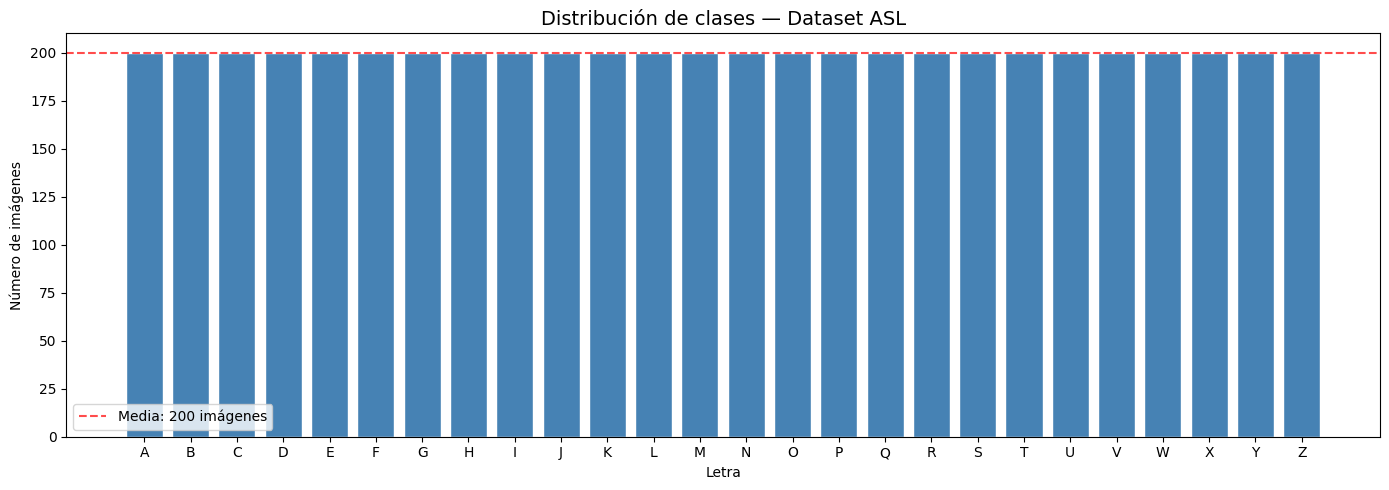

Mínimo por clase : 200 (A)
Máximo por clase : 200 (A)
Media            : 200.0


In [8]:
conteo = df_meta["etiqueta"].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(conteo.index, conteo.values, color="steelblue", edgecolor="white")
plt.title("Distribución de clases — Dataset ASL", fontsize=14)
plt.xlabel("Letra")
plt.ylabel("Número de imágenes")

# Línea de referencia: valor esperado si el dataset fuera perfectamente balanceado
media = conteo.mean()
plt.axhline(y=media, color="red", linestyle="--", alpha=0.7,
            label=f"Media: {media:.0f} imágenes")
plt.legend()
plt.tight_layout()
plt.savefig("distribucion_clases.png", dpi=150)
plt.show()

print(f"Mínimo por clase : {conteo.min()} ({conteo.idxmin()})")
print(f"Máximo por clase : {conteo.max()} ({conteo.idxmax()})")
print(f"Media            : {conteo.mean():.1f}")

A partir del script de exploración, sabemos que contamos con un dataset  balanceado, descartando entonces tecnicas de sobremuestreo y se confirma con la media que tenemos un dataset perfectamente balanceado.


## NOTA!!!
Explorando visualmente las imagenes, encontramos que existe un padding y un borde magenta. Usando Image_1_1748983683.04.jpg vemos:


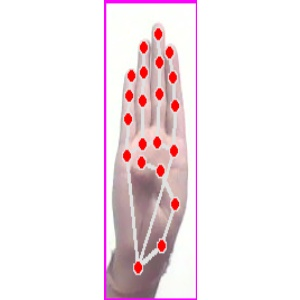 

En la exploración visual del dataset encontramos que aunque tenemos imagenes cuadradas en todo el dataset, tenemos un preprocesamiento del tipo Padding en el mismo. Por ende, es conveniente realizar un crop para retirar pixeles que no aportarán precisión en el entrenamiento, generan ruido cosas como esta, por ejemplo, el modelo aprendería sobre el borde y no necesariamente la forma de la mano.

Este es un paso necesario para modelos de aprendizaje de maquinas clasico, donde si utilizaramos el dataset original, tendriamos imagenes de 300x300 convirtiendose un arreglo de 90.000 variables predictoras como columnas y 5200 filas que corresponde cada imagen y contaría con un costo computacional elevado, que se puede reducir sin perder demasiada precisión.

Utilizando el borde morado, podemos eliminar estos datos usando:

# Preprocesamiento: ELIMINACIÓN MEDIANTE CROP

## Que hace este codigo?

Este codigo recorta el Padding proveniente del Dataset Original, porque no tiene nada que ver con la seña que el modelo debe aprender. Si lo dejasemos, el modelo lo incluirá en su aprendizaje, siendo un recuadro en la seña algo inexistente en el mundo real. Usamos HSV para agrupar de mejor forma el borde magenta/morado. 

Luego, calcula una Bounding Box, del margen magenta/morado y retira lo que este fuera de la bounding box, restando pixeles y manteniendo la seña intacta.

Los valores HSV se eligieron inspeccionando el color del borde visualmente y mapeándolo al espacio HSV de OpenCV. H entre 130 y 170 cubre el rango morado-magenta. S y V con mínimo 80 excluyen píxeles oscuros y grises que accidentalmente caigan en ese rango de matiz. El margen de 6 píxeles compensa los artefactos de compresión JPEG en los bordes del marco.

In [9]:


LOWER_PURPLE = np.array([130,  80,  80], dtype=np.uint8)  # límite inferior HSV
UPPER_PURPLE = np.array([170, 255, 255], dtype=np.uint8)  # límite superior HSV
MARGEN       = 6  # píxeles a descartar del borde detectado

procesadas = 0
sin_borde  = 0
errores    = []

clases = sorted([
    d for d in os.listdir(DATASET_RAW)
    if os.path.isdir(os.path.join(DATASET_RAW, d))
])

for clase in clases:
    carpeta_entrada = os.path.join(DATASET_RAW, clase)
    carpeta_salida  = os.path.join(DATASET_CROPPED, clase)
    os.makedirs(carpeta_salida, exist_ok=True)  # crea la carpeta si no existe

    for archivo in os.listdir(carpeta_entrada):
        if not archivo.lower().endswith(".jpg"):
            continue

        ruta = os.path.join(carpeta_entrada, archivo)
        img  = cv2.imread(ruta)
        if img is None:
            errores.append(ruta)
            continue

        # Convertir BGR → HSV para detectar el color morado
        hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, LOWER_PURPLE, UPPER_PURPLE)

        # Dilatar la máscara para conectar píxeles del borde fragmentados por compresión JPEG
        kernel = np.ones((3, 3), np.uint8)
        mask   = cv2.dilate(mask, kernel, iterations=1)

        contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contornos) == 0:
            img_crop = img   # sin borde detectado: guardar tal cual
            sin_borde += 1
        else:
            contorno_mayor = max(contornos, key=cv2.contourArea)
            x, y, w, h     = cv2.boundingRect(contorno_mayor)

            # Recortar DENTRO del borde sumando el margen
            x1 = max(0, x + MARGEN)
            y1 = max(0, y + MARGEN)
            x2 = min(img.shape[1], x + w - MARGEN)
            y2 = min(img.shape[0], y + h - MARGEN)

            img_crop = img[y1:y2, x1:x2]

        ruta_salida = os.path.join(carpeta_salida, archivo)
        cv2.imwrite(ruta_salida, img_crop)
        procesadas += 1

print(f"Procesadas correctamente : {procesadas}")
print(f"Sin borde detectado      : {sin_borde}  (guardadas sin recorte)")
print(f"Errores de lectura       : {len(errores)}")

Procesadas correctamente : 5200
Sin borde detectado      : 0  (guardadas sin recorte)
Errores de lectura       : 0


# Observacion de tamaños despues de aplicar CROP.

Despues del recorte, es muy plausible que las imagenes no sean del mismo tamaño, usando el mismo ejemplo de la imagen Image_1_1748983683.04.jpg la vemos así:

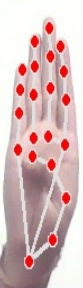

Por ende, debemos saber como se comporta ahora el tamaño de los datos. Hacemos:

In [10]:
anchos, altos = [], []

for clase in os.listdir(DATASET_CROPPED):
    carpeta = os.path.join(DATASET_CROPPED, clase)
    if not os.path.isdir(carpeta):
        continue
    for archivo in os.listdir(carpeta):
        ruta = os.path.join(carpeta, archivo)
        img  = cv2.imread(ruta)
        if img is not None:
            h, w = img.shape[:2]
            anchos.append(w)
            altos.append(h)

print(f"Ancho  — min: {min(anchos)}, max: {max(anchos)}, promedio: {np.mean(anchos):.0f}")
print(f"Alto   — min: {min(altos)},  max: {max(altos)},  promedio: {np.mean(altos):.0f}")
print(f"Total imágenes medidas: {len(anchos)}")

Ancho  — min: 80, max: 288, promedio: 206
Alto   — min: 136,  max: 288,  promedio: 269
Total imágenes medidas: 5200




Al observar el promedio del tamaño de las imagenes, sus altos y minimos, llegamos a la conclusión de que es necesario redimensionar las imagenes del dataset a partir de un Resize. Esto comprende el proceso de preprocesamiento de los datos. Decidimos utilizar un tamaño de 128x128 para las nuevas imagenes redimensionadas.

# Preprocesamiento: Resize 128x128

Con cv2.resize() de OpenCV, usamos de entrada la imagen original del dataset y el tamaño destino. Lo importante es el método de interpolación, que es el algoritmo que decide qué valor darle a los píxeles nuevos o cuáles eliminar:

- ``INTER_AREA``: para reducir imágenes. Promedia los píxeles vecinos. Produce menos distorsión al achicar.
- ``INTER_LINEAR``: para ampliar imágenes. Estima píxeles nuevos interpolando entre los existentes.

En este dataset la mayoría de imágenes son más grandes que 128×128 después del crop, así que se usa principalmente ``INTER_AREA.``


In [11]:

# INTER_AREA: mejor calidad al REDUCIR (evita aliasing).
# INTER_LINEAR: mejor calidad al AMPLIAR.

TARGET_SIZE = (128, 128)
procesadas  = 0
errores     = []

clases = sorted([
    d for d in os.listdir(DATASET_CROPPED)
    if os.path.isdir(os.path.join(DATASET_CROPPED, d))
])

for clase in clases:
    carpeta_entrada = os.path.join(DATASET_CROPPED, clase)
    carpeta_salida  = os.path.join(DATASET_RESIZED, clase)
    os.makedirs(carpeta_salida, exist_ok=True)

    for archivo in os.listdir(carpeta_entrada):
        if not archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        ruta_entrada = os.path.join(carpeta_entrada, archivo)
        ruta_salida  = os.path.join(DATASET_RESIZED, clase, archivo)

        img = cv2.imread(ruta_entrada)
        if img is None:
            errores.append(ruta_entrada)
            continue

        h, w          = img.shape[:2]
        interpolacion = cv2.INTER_AREA if (w > 128 or h > 128) else cv2.INTER_LINEAR
        img_resized   = cv2.resize(img, TARGET_SIZE, interpolation=interpolacion)

        cv2.imwrite(ruta_salida, img_resized)
        procesadas += 1

print(f"Procesadas : {procesadas}")
print(f"Errores    : {len(errores)}")

Procesadas : 5200
Errores    : 0


Con esto, tenemos un dataset con imagenes cuadradas, apto para modelos de deep learning, como Redes Neuronales Convolutivas (CNN), y modelos de machine learning clasicos que requieren una vectorizacion de los datos, al ser menos, reducimos por encima del 50% su costo computacional. 

# Preprocesamiento: Escala de Grises

Al inicio del notebook, encontramos tanto explorativamente como visualmente que las imagenes se encuentran en formato RGB. 
- Una imagen RGB de 128×128 tiene 128 × 128 × 3, eso da 49,152 valores por imagen. Al convertirla a escala de grises queda en 128 × 128 × 1 = 16,384 valores. Por ende, Reducimos la dimensionalidad a un tercio sin perder la información relevante.

- Es decir, Convierte cada imagen de 3 canales (R, G, B) a 1 solo canal con valores enteros entre 0 y 255, donde 0 es negro y 255 es blanco.
  
- La información relevante aquí es la forma de la mano, no su color. Todas las manos en el dataset tienen aproximadamente el mismo tono de piel y el fondo es uniforme. El color no aporta nada que ayude a distinguir una seña de otra. La forma, la posición de los dedos y las sombras sí lo hacen, y todo eso está preservado en la escala de grises.

- Ahora tendríamos unos arreglos de 128x128, dando 13.684 variables predictoras como columnas, y 5200 filas; con una variable a predecir siendo su correspondiente clase.

In [12]:
# OpenCV usa la fórmula ponderada:
#   Gray = 0.114·R + 0.587·G + 0.299·B
# que aproxima la percepción humana del brillo.

procesadas = 0
errores    = []

clases = sorted([
    d for d in os.listdir(DATASET_RESIZED)
    if os.path.isdir(os.path.join(DATASET_RESIZED, d))
])

for clase in clases:
    carpeta_entrada = os.path.join(DATASET_RESIZED, clase)
    carpeta_salida  = os.path.join(DATASET_GRAY, clase)
    os.makedirs(carpeta_salida, exist_ok=True)

    for archivo in os.listdir(carpeta_entrada):
        if not archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        ruta_entrada = os.path.join(carpeta_entrada, archivo)
        ruta_salida  = os.path.join(carpeta_salida, archivo)

        img = cv2.imread(ruta_entrada)
        if img is None:
            errores.append(ruta_entrada)
            continue

        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # BGR → 1 canal
        cv2.imwrite(ruta_salida, img_gray)
        procesadas += 1

print(f"Procesadas : {procesadas}")
print(f"Errores    : {len(errores)}")

Procesadas : 5200
Errores    : 0


Ahora al vectorizar después, cada imagen ocupa una fila de 16,384 columnas en lugar de 49,152. Eso hace que el CSV sea tres veces más pequeño, que PCA converja más rápido y que el entrenamiento de los modelos de aprendizaje de maquinas impartidos en clases sean significativamente menos costosos.

# Verificación antes de vectorizar.
Entonces verificaremos que todo el preprocesamiento anterior funcionó correctamente y que las imágenes están casi listas para entrenar al modelo antes de continuar con vectorización o división del dataset para entrenamiento. Verificaremos lo siguiente:

- Shape (128, 128): confirmará que el resize funcionó. Si aparece otro tamaño, significa que algo falló en la celda 07.
- Dtype uint8: confirmará que los píxeles son enteros entre 0 y 255. Si aparece float32 u otro tipo, quiere decir que hay un problema de conversión.
- Min >= 0 y Max <= 255: verificará que los valores están en el rango esperado para una imagen en escala de grises. Por lo tanto, si el max es 1.0, la imagen fue normalizada accidentalmente antes de tiempo, lo que implica un fallo.


Total imágenes verificadas : 5200
Shape correcta (128,128)   : 5200
Dtype correcto (uint8)     : 5200
Rango correcto [0,255]     : 5200
Errores de lectura         : 0
Errores de shape           : 0
Errores de dtype           : 0
Errores de rango           : 0


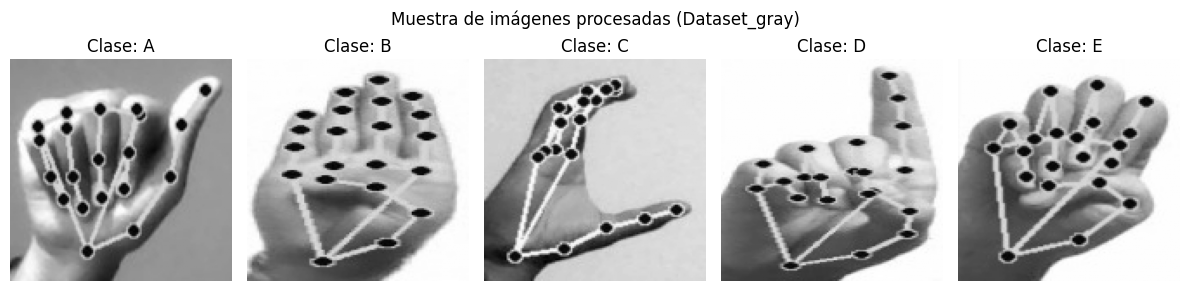

In [13]:
errores_shape = []   # imágenes con tamaño distinto a (128, 128)
errores_dtype = []   # imágenes con tipo de dato distinto a uint8
errores_rango = []   # imágenes con valores fuera de [0, 255]
errores_lectura = [] # imágenes que no se pudieron leer

total = 0

clases = sorted([
    d for d in os.listdir(DATASET_GRAY)
    if os.path.isdir(os.path.join(DATASET_GRAY, d))
])

for clase in clases:
    carpeta = os.path.join(DATASET_GRAY, clase)
    for archivo in os.listdir(carpeta):
        if not archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        ruta = os.path.join(carpeta, archivo)
        img  = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        total += 1

        if img is None:
            errores_lectura.append(ruta)
            continue

        if img.shape != (128, 128):
            errores_shape.append((ruta, img.shape))

        if img.dtype != np.uint8:
            errores_dtype.append((ruta, img.dtype))

        if img.min() < 0 or img.max() > 255:
            errores_rango.append((ruta, img.min(), img.max()))

# ── Reporte estadístico ──────────────────────────────────
print(f"{'='*50}")
print(f"Total imágenes verificadas : {total}")
print(f"Shape correcta (128,128)   : {total - len(errores_shape) - len(errores_lectura)}")
print(f"Dtype correcto (uint8)     : {total - len(errores_dtype) - len(errores_lectura)}")
print(f"Rango correcto [0,255]     : {total - len(errores_rango) - len(errores_lectura)}")
print(f"{'='*50}")
print(f"Errores de lectura         : {len(errores_lectura)}")
print(f"Errores de shape           : {len(errores_shape)}")
print(f"Errores de dtype           : {len(errores_dtype)}")
print(f"Errores de rango           : {len(errores_rango)}")

if errores_shape:
    print("\nImágenes con shape incorrecto:")
    for ruta, shape in errores_shape[:5]:  # mostrar máximo 5
        print(f"  {ruta} → {shape}")

# ── Muestra visual de 5 clases ───────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for ax, clase in zip(axes, clases[:5]):
    archivo = os.listdir(os.path.join(DATASET_GRAY, clase))[0]
    img     = cv2.imread(os.path.join(DATASET_GRAY, clase, archivo),
                         cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Clase: {clase}")
    ax.axis("off")

plt.suptitle("Muestra de imágenes procesadas (Dataset_gray)")
plt.tight_layout()
plt.show()

Gracias a este proceso, resulta factible confiar en el preprocesamiento del Dataset original a la versión que estamos trabajando actualmente. Se debe resaltar que hay imagenes con fondo blanco y otras en grises. Esto se da por las diferencias de la iluminación original, también es porque, directamente, se realizó un recorte en el dataset original en su fondo.

### Analisis sobre el fondo de las imagenes.

Al aplicar escala de grises, logramos observar de forma muy clara que hay ciertas imagenes que cuentan con fondo. Esto resulta preocupante para nosotros, pues cuestionamos cuánto puede influir ese fondo en el entrenamiento, y si podemos obviarlo. Algo así importa porque un modelo entrenado con ambos tipos de fondo sin distinción no aprende solo la forma de la mano: aprende también que ciertas clases "se ven" con fondo texturado y otras con fondo blanco. Eso es sesgo de fondo, no conocimiento de la seña, resulta erróeo. En ese sentido:

In [4]:
UMBRAL_VAR_FONDO = 200

conteo_fondo_blanco   = 0
conteo_fondo_original = 0
rutas_fondo_original  = []

resumen_por_clase = {}

clases = sorted([
    d for d in os.listdir(DATASET_GRAY)
    if os.path.isdir(os.path.join(DATASET_GRAY, d))
])

for clase in clases:
    carpeta = os.path.join(DATASET_GRAY, clase)
    n_blanco   = 0
    n_original = 0

    for archivo in os.listdir(carpeta):
        ruta = os.path.join(carpeta, archivo)
        img  = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        h, w = img.shape
        margen_h = max(1, h // 10)
        margen_w = max(1, w // 10)

        # Tomamos las 4 esquinas donde normalmente está el fondo
        esquinas = [
            img[:margen_h,  :margen_w],
            img[:margen_h,  -margen_w:],
            img[-margen_h:, :margen_w],
            img[-margen_h:, -margen_w:],
        ]

        var_fondo = np.mean([np.var(e.astype(np.float32)) for e in esquinas])

        if var_fondo > UMBRAL_VAR_FONDO:
            n_original += 1
            conteo_fondo_original += 1
            rutas_fondo_original.append(ruta)
        else:
            n_blanco += 1
            conteo_fondo_blanco += 1

    resumen_por_clase[clase] = {"blanco": n_blanco, "original": n_original}

# Reporte
total = conteo_fondo_blanco + conteo_fondo_original

print(f"Total imágenes analizadas : {total}")
print(f"Fondo blanco/uniforme     : {conteo_fondo_blanco}  ({conteo_fondo_blanco/total*100:.1f}%)")
print(f"Fondo original/heterogéneo: {conteo_fondo_original}  ({conteo_fondo_original/total*100:.1f}%)")
print()

print(f"{'Clase':<8} {'Fondo blanco':>14} {'Fondo original':>16} {'% original':>12}")
print("-" * 52)
for clase in clases:
    b = resumen_por_clase[clase]["blanco"]
    o = resumen_por_clase[clase]["original"]
    t = b + o
    pct = o / t * 100 if t > 0 else 0
    print(f"{clase:<8} {b:>14} {o:>16} {pct:>11.1f}%")

print(f"\nRutas guardadas en: rutas_fondo_original ({len(rutas_fondo_original)} imágenes)")

Total imágenes analizadas : 5200
Fondo blanco/uniforme     : 3445  (66.2%)
Fondo original/heterogéneo: 1755  (33.8%)

Clase      Fondo blanco   Fondo original   % original
----------------------------------------------------
A                    10              190        95.0%
B                   189               11         5.5%
C                   200                0         0.0%
D                   177               23        11.5%
E                   200                0         0.0%
F                   186               14         7.0%
G                   115               85        42.5%
H                   141               59        29.5%
I                   200                0         0.0%
J                   129               71        35.5%
K                    32              168        84.0%
L                    59              141        70.5%
M                   119               81        40.5%
N                    83              117        58.5%
O                  

Los resultados muestran que el **33.8% del dataset tiene fondo original**, y la distribución por clase no es aleatoria ni estpa balanceada, sino que es sistemática: clases como S (97.5%), V (95.5%), A (95%) y K (84%) tienen casi toda su representación sobre fondo heterogéneo, mientras que C, E, I, P, X e Y tienen fondo blanco en el 100% de sus imágenes. Así que probaremos cómo nos va implementando OTSU.

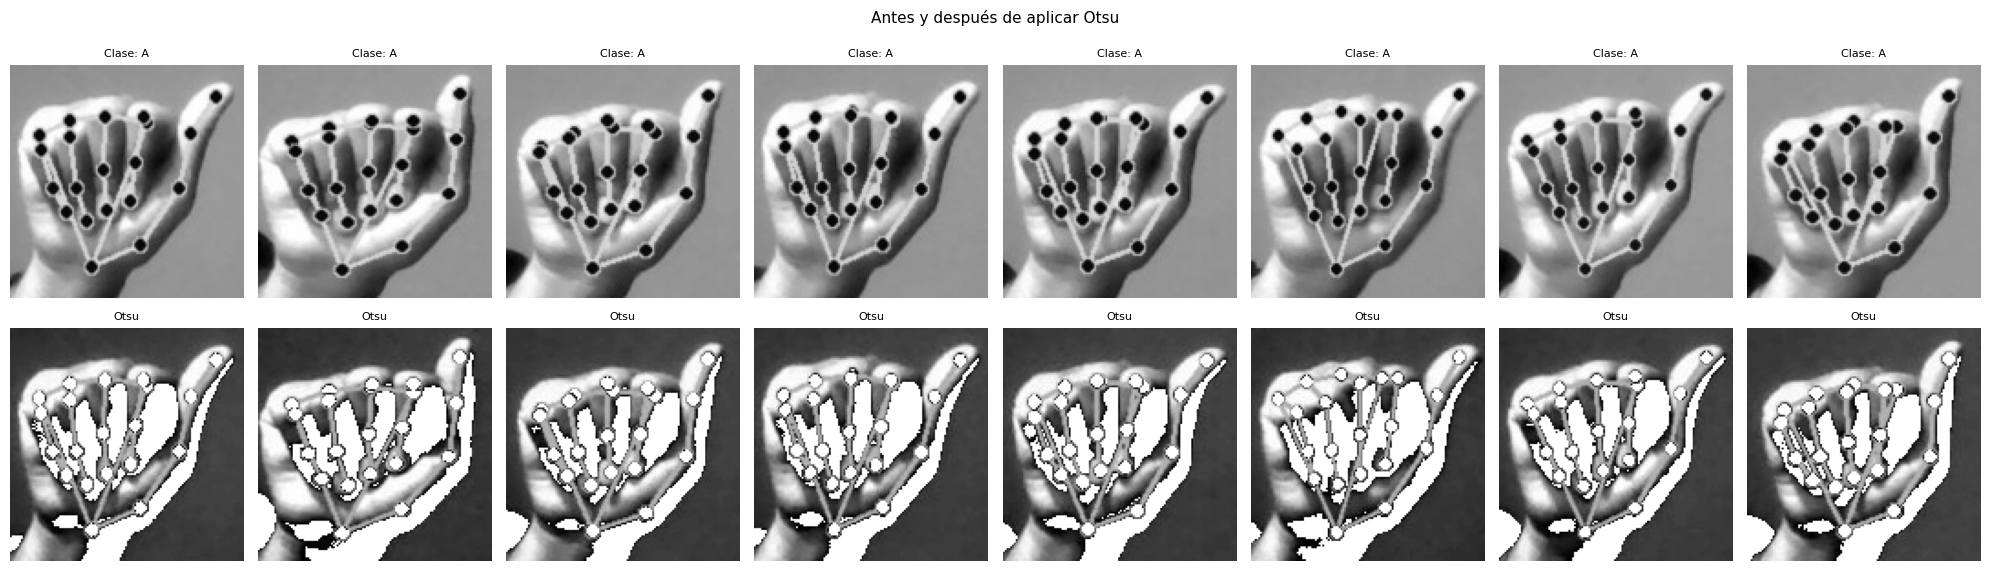

In [6]:

# Tomamos una muestra pequeña de las imágenes con fondo original
muestra = rutas_fondo_original[:8]

fig, axes = plt.subplots(2, 8, figsize=(20, 6))

for i, ruta in enumerate(muestra):
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    # Aplicamos Otsu
    _, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # El fondo oscuro queda en negro con Otsu, lo invertimos para que quede blanco
    otsu_inv = cv2.bitwise_not(otsu)

    # Reemplazamos el fondo por blanco en la imagen original
    resultado = img.copy()
    resultado[otsu_inv == 255] = 255

    clase = ruta.split(os.sep)[-2]

    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"Clase: {clase}", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(resultado, cmap="gray")
    axes[1, i].set_title("Otsu", fontsize=8)
    axes[1, i].axis("off")

plt.suptitle("Antes y después de aplicar Otsu", fontsize=11)
plt.tight_layout()
plt.show()

Cuando aplicamos Otsu sobre una muestra de imágenes con fondo original, el resultado fue inesperado para nosotros. El algoritmo encuentra un umbral que separa píxeles oscuros de píxeles claros, sin embargo, en estas imágenes hay tres grupos de intensidad presentes: el fondo gris, la piel de la mano en tonos medios, y los puntos de referencia superpuestos en la mano, que quedaron en negro.

Al invertir la máscara para dejar el fondo en blanco, los puntos de referencia negros se clasifican como fondo y se vuelven blancos, esto distronionó la estructura de la mano que el modelo debe aprender, también capturó las sombras de la mano como si fuesen fondo.

Por tal motivo, Otsu no es aplicable a este dataset. La presencia de puntos de refencia en todas las imágenes del dataset altera el histograma de intensidades y hace que el umbral automático no corresponda a la separación real entre mano y fondo. El dataset se mantiene en su estado actual desde `Dataset_gray`.

# Vectorización del Dataset.

Convertimos cada imagen en una fila de números para poder trabajar con ella en modelos de ML clásicos, tales como árbol de decisión y random forest. Cada imagen es una matriz de píxeles. Pero un árbol de decisión no entiende matrices, solo puede entender filas de valores con columnas etiquetadas. Entonces hay que transformar cada imagen en una estructura tabular. Usamos Flatten() para leer todos los pixeles de la imagen de izquierda a derecha.

In [18]:
filas  = []
labels = []

clases = sorted([
    d for d in os.listdir(DATASET_GRAY)
    if os.path.isdir(os.path.join(DATASET_GRAY, d))
])

for clase in clases:
    carpeta  = os.path.join(DATASET_GRAY, clase)
    archivos = [f for f in os.listdir(carpeta)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for archivo in archivos:
        ruta = os.path.join(carpeta, archivo)
        img  = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        filas.append(img.flatten())  # (128,128) → (16384,)
        labels.append(clase)

# Nombres de columnas: pixel_0, pixel_1, ..., pixel_16383
columnas = [f"pixel_{i}" for i in range(128 * 128)]
df_vec   = pd.DataFrame(filas, columns=columnas)
df_vec["label"] = labels

df_vec.to_csv(CSV_VECTORIZADO, index=False)

print(f"Shape del CSV : {df_vec.shape}")   # debe ser (5200, 16385)
print(f"Guardado en   : {CSV_VECTORIZADO}")

# ── Inspección en tres zonas del dataset ─────────────────
print("\n=== Inicio (clase A) ===")
display(df_vec.head())

print("\n=== Mitad (clase N) ===")
mitad = len(df_vec) // 2
display(df_vec.iloc[mitad:mitad+5])

print("\n=== Final (clase Z) ===")
display(df_vec.tail())

Shape del CSV : (5200, 16385)
Guardado en   : /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/asl_dataset.csv

=== Inicio (clase A) ===


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_16375,pixel_16376,pixel_16377,pixel_16378,pixel_16379,pixel_16380,pixel_16381,pixel_16382,pixel_16383,label
0,173,173,173,172,171,171,171,171,171,171,...,177,177,177,177,177,176,176,176,175,A
1,175,175,175,176,176,176,177,177,176,176,...,177,175,175,175,176,176,176,176,176,A
2,175,175,175,175,175,175,175,175,175,175,...,177,177,177,177,177,176,175,175,176,A
3,172,173,174,174,174,174,174,175,176,176,...,178,178,178,178,178,178,177,177,177,A
4,173,174,175,175,175,175,175,176,177,176,...,177,177,177,177,178,178,177,177,177,A



=== Mitad (clase N) ===


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_16375,pixel_16376,pixel_16377,pixel_16378,pixel_16379,pixel_16380,pixel_16381,pixel_16382,pixel_16383,label
2600,246,250,252,251,251,251,250,251,251,251,...,253,253,253,254,253,253,252,253,253,N
2601,252,253,253,252,252,252,252,252,252,252,...,254,254,253,253,253,254,254,254,253,N
2602,249,253,252,252,253,252,254,253,253,253,...,253,253,253,253,253,254,254,254,254,N
2603,252,252,252,252,252,253,253,252,253,253,...,254,254,253,253,254,254,254,253,253,N
2604,248,252,253,252,252,252,251,253,253,253,...,253,254,254,254,254,254,254,253,253,N



=== Final (clase Z) ===


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_16375,pixel_16376,pixel_16377,pixel_16378,pixel_16379,pixel_16380,pixel_16381,pixel_16382,pixel_16383,label
5195,254,253,253,253,254,254,254,254,254,254,...,254,254,254,254,254,254,254,254,254,Z
5196,253,253,254,254,254,254,254,254,254,254,...,254,254,254,254,254,254,254,254,254,Z
5197,253,253,254,254,254,254,254,254,254,254,...,254,254,254,254,254,254,254,254,254,Z
5198,255,255,255,254,254,254,254,254,254,254,...,254,254,254,254,254,254,254,254,254,Z
5199,254,254,254,254,254,254,254,254,254,254,...,254,254,254,254,254,254,254,253,253,Z


Este paso es importante para implementar Árboles de Decisión y Random Forest, sin embargo, 16.384 variables predictoras llevan a "la maldición de dimensionalidad", así que implementamos Análisis de Componentes Principales (PCA) a fin de reducir esta gran cantidad a un numero mucho más manejable.

## Análisis de distribución de intensidad de píxeles

Antes de entrenar cualquier modelo, es necesario verificar cómo están distribuidos los valores de intensidad en el dataset. Esta distribución revela qué tipo de información contienen realmente los píxeles que el modelo va a recibir como entrada y qué tan diferentes son las imágenes entre sí. Si la mayoría de los píxeles tienen valores similares entre imágenes, el modelo tiene poco material con qué trabajar para distinguir una clase de otra.

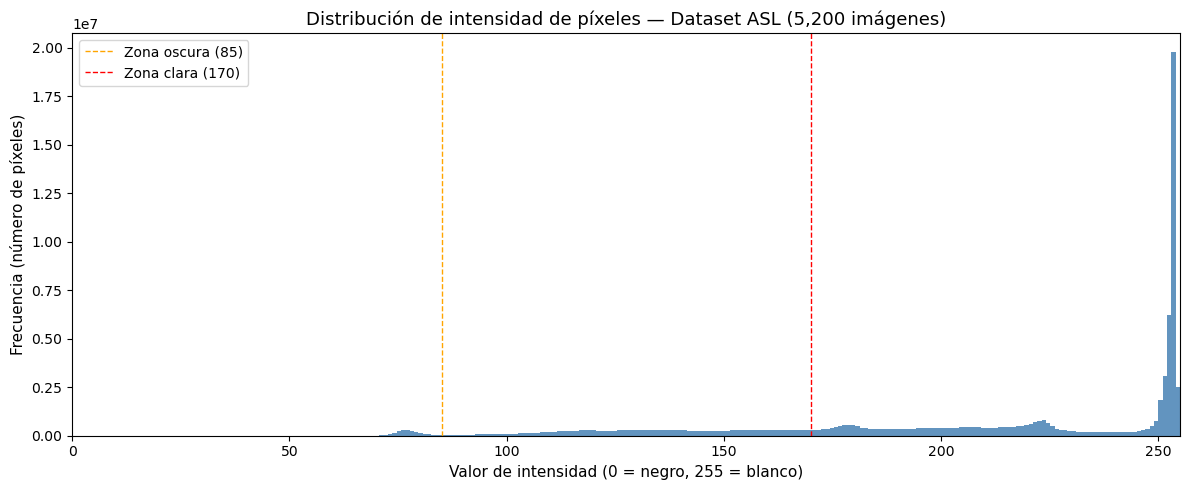


Estadísticas globales de intensidad:
  Media    : 206.94
  Std      : 51.54
  Mínimo   : 36
  Máximo   : 255


In [5]:
df_hist = pd.read_csv(CSV_VECTORIZADO)

# Separar las columnas de píxeles (todas menos "label")
pixel_cols = [c for c in df_hist.columns if c.startswith("pixel_")]

todos_los_pixeles = df_hist[pixel_cols].values.flatten()

# ── Graficar ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    todos_los_pixeles,
    bins=256,           # un bin por cada valor posible de intensidad (0–255)
    range=(0, 255),     # rango fijo para que el eje X sea siempre comparable
    color="steelblue",
    edgecolor="none",
    alpha=0.85
)

ax.set_title("Distribución de intensidad de píxeles — Dataset ASL (5,200 imágenes)", fontsize=13)
ax.set_xlabel("Valor de intensidad (0 = negro, 255 = blanco)", fontsize=11)
ax.set_ylabel("Frecuencia (número de píxeles)", fontsize=11)
ax.set_xlim(0, 255)

# Líneas de referencia para zonas oscuras, medias y claras
ax.axvline(x=85,  color="orange", linestyle="--", linewidth=1, label="Zona oscura (85)")
ax.axvline(x=170, color="red",    linestyle="--", linewidth=1, label="Zona clara (170)")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("histograma_intensidad_global.png", dpi=150)
plt.show()

print(f"\nEstadísticas globales de intensidad:")
print(f"  Media    : {todos_los_pixeles.mean():.2f}")
print(f"  Std      : {todos_los_pixeles.std():.2f}")
print(f"  Mínimo   : {todos_los_pixeles.min()}")
print(f"  Máximo   : {todos_los_pixeles.max()}")

El histograma muestra una distribución con dos acumulaciones bien diferenciadas. Por un lado está la pila más grande con valores concentrados cerca del 255, que es la que corresponde al fondo blanco uniforme que aparece prácticamente en la mayoría de las imágenes. Y por el otro lado, la pila más pequeña que toma valores entre 80 y 170 aproximadamente y es la que corresponde a los píxeles de la mano. Por último se denota que el valor mínimo de 36 confirma que no hay zonas completamente negras en el dataset.

Como estadisticas globales se tiene que la media de 206.94 está sesgada hacia valores altos precisamente porque el fondo blanco domina la distribución. Por su parte la desviación estándar de 51.54 demuestra variabilidad moderada: es precisamente la varianza que PCA va a capturar y comprimir en sus componentes principales.

Los píxeles del fondo tienen valores similares en todas las imágenes, independientemente de la letra que se esté haciendo. Los píxeles de la mano, en cambio, varían según la posición de los dedos en cada seña. Esto significa que la información que realmente distingue una clase de otra no está repartida uniformemente entre los 16,384 píxeles de cada imagen que está concentrada en el 
subconjunto que describe la mano. Esa concentración de información es lo que hace viable reducir la dimensionalidad del dataset sin perder capacidad discriminativa, como se verá a continuación en la sección de PCA.

# Analisis de componentes principales (PCA)

Debemos reducir la dimensionalidad de la vectorización del dataset, pero su escogencia no es un numero al azar.
- Si eliges muy pocos pierdes demasiada información y el modelo clasifica mal.
- Si eliges demasiados, no estás reduciendo nada útil y el entrenamiento sigue siendo costoso.

PCA Toma las columnas de pixeles y las transforma en un número menor de columnas nuevas llamadas componentes. Cada componente es una combinación de los píxeles originales que captura un patrón de variación en el dataset.

In [7]:

df_pca_diag = pd.read_csv(CSV_VECTORIZADO)
X_diag      = df_pca_diag.drop(columns=["label"]).values
y_diag      = df_pca_diag["label"].values

print("Normalizando datos...")
scaler_diag = StandardScaler()
X_diag_sc   = scaler_diag.fit_transform(X_diag)

# Calcular todos los componentes posibles
n_max = min(X_diag_sc.shape[0], X_diag_sc.shape[1])
print(f"Calculando PCA con {n_max} componentes... (puede tardar varios minutos)")

pca_diag      = PCA(n_components=n_max, random_state=42)
pca_diag.fit(X_diag_sc)
varianza_acum = np.cumsum(pca_diag.explained_variance_ratio_) * 100

print("Cálculo completado.")

# ── Tabla de umbrales ─────────────────────────────────────
umbrales = [90, 95, 97, 99]
puntos   = {}
for u in umbrales:
    n = int(np.argmax(varianza_acum >= u)) + 1
    puntos[u] = n

print(f"\n{'Umbral':>8} | {'Componentes necesarios':>22}")
print("-" * 34)
for u, n in puntos.items():
    print(f"{u:>7}% | {n:>22}")

Normalizando datos...
Calculando PCA con 5200 componentes... (puede tardar varios minutos)
Cálculo completado.

  Umbral | Componentes necesarios
----------------------------------
     90% |                    126
     95% |                    361
     97% |                    665
     99% |                   1642


La tabla muestra cuántos componentes necesita cada umbral. Con 90% de varianza acumulada bastan 126 componentes, pero esa compresión tan agresiva puede descartar detalles finos de la forma de los dedos que diferencian señas similares. El 99% requiere 1,642 componentes, lo que sigue siendo costoso sin justificación proporcional. El 95% con 361 componentes y el 97% con 665 son los puntos de equilibrio razonables: conservan suficiente detalle para distinguir señas similares sin el costo de trabajar con miles de columnas.

Se generaron representaciones para ambos umbrales, pero los experimentos confirmaron que con 95% todos los modelos alcanzaron accuracy de 1.0. Los 304 componentes adicionales del 97% no aportaron ninguna mejora, así que los modelos clásicos se entrenaron únicamente sobre la representación al 95%.

## Grafica codo

La gráfica muestra cómo crece la varianza acumulada a medida que se suman componentes principales. En el panel izquierdo se ve la curva completa: el crecimiento es muy pronunciado en los primeros componentes y luego se aplana progresivamente, formando el "codo" característico de PCA. Eso significa que los primeros componentes capturan la mayor parte de la información del dataset, y los siguientes aportan cada vez menos.

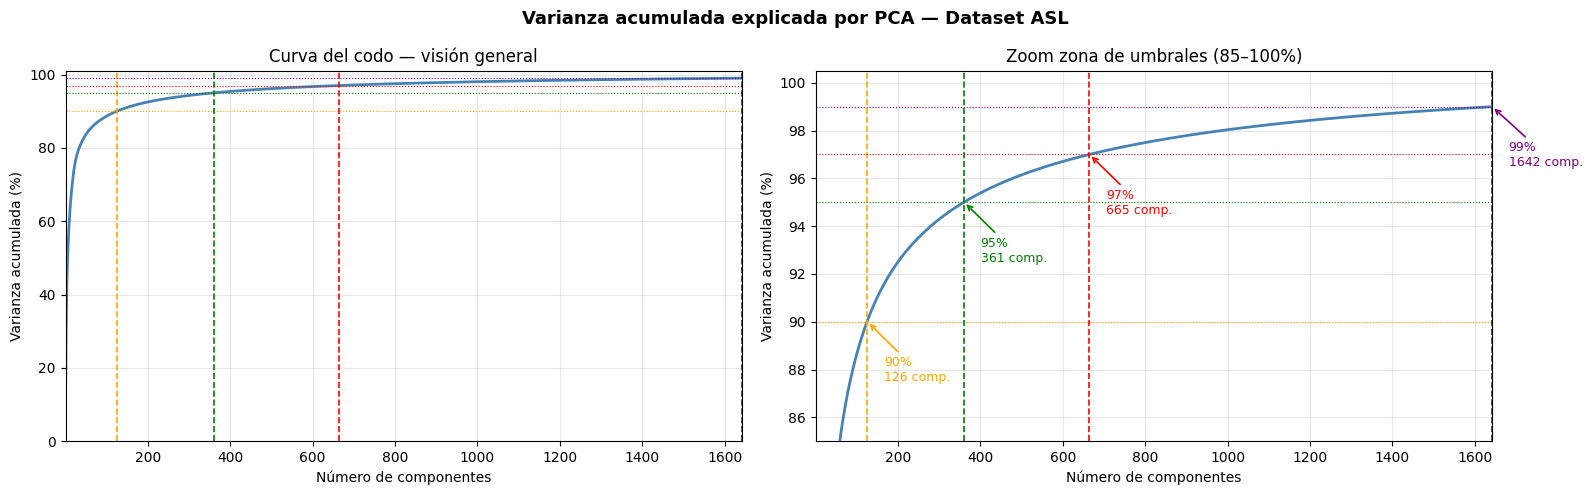

In [9]:
n_99 = puntos[99]
colores = {90: 'orange', 95: 'green', 97: 'red', 99: 'purple'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ── Panel izquierdo: curva completa ───────────────────────
ax1.plot(range(1, n_99 + 1), varianza_acum[:n_99],
         color='steelblue', linewidth=2)
ax1.set_title("Curva del codo — visión general", fontsize=12)
ax1.set_xlabel("Número de componentes")
ax1.set_ylabel("Varianza acumulada (%)")
ax1.set_xlim(1, n_99)
ax1.set_ylim(0, 101)
ax1.grid(True, alpha=0.3)

for umbral, n in puntos.items():
    ax1.axvline(x=n, color=colores[umbral], linestyle='--', linewidth=1.2)
    ax1.axhline(y=umbral, color=colores[umbral], linestyle=':', linewidth=0.8)

# ── Panel derecho: zoom en la zona del codo (85–100%) ─────
ax2.plot(range(1, n_99 + 1), varianza_acum[:n_99],
         color='steelblue', linewidth=2)
ax2.set_title("Zoom zona de umbrales (85–100%)", fontsize=12)
ax2.set_xlabel("Número de componentes")
ax2.set_ylabel("Varianza acumulada (%)")
ax2.set_xlim(1, n_99)
ax2.set_ylim(85, 100.5)
ax2.grid(True, alpha=0.3)

for umbral, n in puntos.items():
    ax2.axvline(x=n, color=colores[umbral], linestyle='--', linewidth=1.2)
    ax2.axhline(y=umbral, color=colores[umbral], linestyle=':', linewidth=0.8)
    ax2.annotate(
        f"{umbral}%\n{n} comp.",
        xy=(n, umbral),
        xytext=(n + 40, umbral - 2.5),
        fontsize=9,
        color=colores[umbral],
        arrowprops=dict(arrowstyle='->', color=colores[umbral], lw=1.2)
    )

plt.suptitle("Varianza acumulada explicada por PCA — Dataset ASL", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("pca_varianza_acumulada.png", dpi=150)
plt.show()

En el panel derecho se hace zoom en la zona de decisión (85–100%) donde están los cuatro umbrales evaluados. Posterior a ello se visualiza mejor y se evidencia que la diferencia entre 90% y 95% requiere pasar de 126 a 361 componentes, es decir, 235 componentes adicionales para ganar solo 5% de varianza. Luego, entre 95% y 97% se necesitan 304 componentes más para recuperar apenas 2% adicional. Esto muestra que la ganancia de información por componente decrece rápidamente a partir del codo.

Así pues se escogieron 361 componentes (95%) y 665 componentes (97%) como puntos de equilibrio para entrenar los modelos clásicos, que conservan suficiente información para distinguir 
señas similares sin el costo de trabajar con miles de columnas. Descartando el 90% por pérdida excesiva de detalle y el 99% por su alto costo computacional sin ganancia proporcional.

Eso sí, aunque se generaron representaciones para ambos umbrales, los experimentos confirmaron que con el 95% todos los modelos alcanzaron accuracy de 1.0. Eso significa que con 361 componentes el modelo ya clasifica correctamente el 100% de los casos del dataset de modo que no hay margen de mejora posible. Agregar 304 componentes más no puede subir una métrica que ya está en su techo, así que el costo computacional extra del 97% no estaba justificado. Los modelos clásicos se entrenaron únicamente sobre la representación al 95%.

## Almacenamiento del modelo PCA

Después de calcular PCA, se guardó el modelo entrenado en un archivo `.pkl`, que contiene la fórmula exacta de transformación al combinar los 16,384 píxeles de cualquier imagen nueva para producir los 361 o 665 componentes en el mismo espacio que usaron los modelos durante el entrenamiento. Cuando llegue una imagen nueva, hay que aplicarle exactamente la misma transformación que se usó durante el entrenamiento para que los componentes resultantes estén en el mismo espacio que el modelo aprendió a interpretar.

Sin este archivo, clasificar una imagen nueva implica recalcular PCA desde cero sobre datos distintos, y un PCA recalculado sobre datos distintos produciría componentes incompatibles con los que el modelo aprendió a interpretar. El `.pkl` es la memoria del preprocesamiento.

### PCA al 95%

In [27]:
scaler_95 = StandardScaler()
X_95      = scaler_95.fit_transform(X_diag)

pca_95    = PCA(n_components=361, random_state=42)
X_pca_95  = pca_95.fit_transform(X_95)

print(f"Shape original : {X_diag.shape}")
print(f"Shape reducido : {X_pca_95.shape}")
print(f"Varianza total : {pca_95.explained_variance_ratio_.sum()*100:.2f}%")

cols_95   = [f"comp_{i}" for i in range(361)]
df_out_95 = pd.DataFrame(X_pca_95, columns=cols_95)
df_out_95["label"] = y_diag
df_out_95.to_csv(CSV_PCA_95, index=False)

with open(PKL_PCA_95, "wb") as f:
    pickle.dump(pca_95, f)

print(f"\nCSV guardado : {CSV_PCA_95}")
print(f"Modelo PCA   : {PKL_PCA_95}")

Shape original : (5200, 16384)
Shape reducido : (5200, 361)
Varianza total : 95.00%

CSV guardado : /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/asl_pca_95.csv
Modelo PCA   : /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/pca_model_95.pkl


### PCA AL 97%

In [30]:
pca_97    = PCA(n_components=665, random_state=42)
X_pca_97  = pca_97.fit_transform(X_95)

print(f"Shape original : {X_diag.shape}")
print(f"Shape reducido : {X_pca_97.shape}")
print(f"Varianza total : {pca_97.explained_variance_ratio_.sum()*100:.2f}%")

cols_97   = [f"comp_{i}" for i in range(665)]
df_out_97 = pd.DataFrame(X_pca_97, columns=cols_97)
df_out_97["label"] = y_diag
df_out_97.to_csv(CSV_PCA_97, index=False)

with open(PKL_PCA_97, "wb") as f:
    pickle.dump(pca_97, f)

print(f"\nCSV guardado : {CSV_PCA_97}")
print(f"Modelo PCA   : {PKL_PCA_97}")

Shape original : (5200, 16384)
Shape reducido : (5200, 665)
Varianza total : 96.97%

CSV guardado : /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/asl_pca_97.csv
Modelo PCA   : /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/pca_model_97.pkl


# División para entrenamiento de los modelos

La división del dataset es necesaria porque entrenar y evaluar el modelo sobre los mismos datos produce overfitting del modelo aplicado, es decir no se mide nada util porque memoriza lo que ya vio en lugar de aprender. 

La división del dataset queda entonces así:  el conjunto de entrenamiento (70%), que es con lo que el modelo aprende; validación (15%), que se usa durante el entrenamiento para detectar si el modelo está memorizando en lugar de generalizar; y prueba (15%), que se reserva completamente hasta el final para medir el rendimiento real una sola vez. 

In [32]:
os.makedirs(os.path.join(ENTRENA_DIR, "vectorizado_95"), exist_ok=True)
os.makedirs(os.path.join(ENTRENA_DIR, "vectorizado_97"), exist_ok=True)
os.makedirs(os.path.join(ENTRENA_DIR, "cnn", "train"),   exist_ok=True)
os.makedirs(os.path.join(ENTRENA_DIR, "cnn", "val"),     exist_ok=True)
os.makedirs(os.path.join(ENTRENA_DIR, "cnn", "test"),    exist_ok=True)

# ── A) División para árboles — PCA 95% ───────────────────
df_95 = pd.read_csv(CSV_PCA_95)

df_95_train, df_95_temp = train_test_split(
    df_95, test_size=0.30, random_state=42, stratify=df_95["label"]
)
df_95_val, df_95_test = train_test_split(
    df_95_temp, test_size=0.50, random_state=42, stratify=df_95_temp["label"]
)

df_95_train.to_csv(os.path.join(ENTRENA_DIR, "vectorizado_95", "train.csv"), index=False)
df_95_val.to_csv(  os.path.join(ENTRENA_DIR, "vectorizado_95", "val.csv"),   index=False)
df_95_test.to_csv( os.path.join(ENTRENA_DIR, "vectorizado_95", "test.csv"),  index=False)

print("División para árboles — PCA 95%:")
print(f"  Train : {df_95_train.shape}  ({len(df_95_train)/len(df_95)*100:.1f}%)")
print(f"  Val   : {df_95_val.shape}    ({len(df_95_val)/len(df_95)*100:.1f}%)")
print(f"  Test  : {df_95_test.shape}   ({len(df_95_test)/len(df_95)*100:.1f}%)")

# ── B) División para árboles — PCA 97% ───────────────────
df_97 = pd.read_csv(CSV_PCA_97)

df_97_train, df_97_temp = train_test_split(
    df_97, test_size=0.30, random_state=42, stratify=df_97["label"]
)
df_97_val, df_97_test = train_test_split(
    df_97_temp, test_size=0.50, random_state=42, stratify=df_97_temp["label"]
)

df_97_train.to_csv(os.path.join(ENTRENA_DIR, "vectorizado_97", "train.csv"), index=False)
df_97_val.to_csv(  os.path.join(ENTRENA_DIR, "vectorizado_97", "val.csv"),   index=False)
df_97_test.to_csv( os.path.join(ENTRENA_DIR, "vectorizado_97", "test.csv"),  index=False)

print("\nDivisión para árboles — PCA 97%:")
print(f"  Train : {df_97_train.shape}  ({len(df_97_train)/len(df_97)*100:.1f}%)")
print(f"  Val   : {df_97_val.shape}    ({len(df_97_val)/len(df_97)*100:.1f}%)")
print(f"  Test  : {df_97_test.shape}   ({len(df_97_test)/len(df_97)*100:.1f}%)")

# ── C) División para CNN (carpetas físicas) ───────────────
rutas, etiquetas = [], []

for clase in sorted(os.listdir(DATASET_GRAY)):
    carpeta = os.path.join(DATASET_GRAY, clase)
    if not os.path.isdir(carpeta):
        continue
    for archivo in os.listdir(carpeta):
        if archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            rutas.append(os.path.join(carpeta, archivo))
            etiquetas.append(clase)

df_cnn = pd.DataFrame({"ruta": rutas, "label": etiquetas})

df_cnn_train, df_cnn_temp = train_test_split(
    df_cnn, test_size=0.30, random_state=42, stratify=df_cnn["label"]
)
df_cnn_val, df_cnn_test = train_test_split(
    df_cnn_temp, test_size=0.50, random_state=42, stratify=df_cnn_temp["label"]
)

for split_nombre, df_split in [("train", df_cnn_train),
                                ("val",   df_cnn_val),
                                ("test",  df_cnn_test)]:
    copiadas = 0
    for _, fila in df_split.iterrows():
        dest = os.path.join(ENTRENA_DIR, "cnn", split_nombre, fila["label"])
        os.makedirs(dest, exist_ok=True)
        shutil.copy2(fila["ruta"], os.path.join(dest, os.path.basename(fila["ruta"])))
        copiadas += 1
    print(f"  CNN {split_nombre:5s}: {copiadas} imágenes copiadas")

print(f"\nEstructura guardada en: {ENTRENA_DIR}")

División para árboles — PCA 95%:
  Train : (3640, 362)  (70.0%)
  Val   : (780, 362)    (15.0%)
  Test  : (780, 362)   (15.0%)

División para árboles — PCA 97%:
  Train : (3640, 666)  (70.0%)
  Val   : (780, 666)    (15.0%)
  Test  : (780, 666)   (15.0%)
  CNN train: 3640 imágenes copiadas
  CNN val  : 780 imágenes copiadas
  CNN test : 780 imágenes copiadas

Estructura guardada en: /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/Entrenamiento


Esto garantiza que las 26 clases estén representadas proporcionalmente en los tres conjuntos, evitando que por azar alguna letra quede sub-representada en la evaluación. Esta división se hace una sola vez y se aplica tanto a los modelos clásicos como a la CNN, para que la comparación entre modelos sea justa y los resultados sean comparables entre sí.

# Arboles de decisión

Un árbol de decisión es un modelo que aprende reglas de clasificación en forma de preguntas binarias en secuencia sobre los componentes PCA: "¿el componente PCA_1 es mayor que X?" "¿el componente 5 es menor que Y?". Cada pregunta divide el espacio de características en dos grupos, y el proceso se repite nodo a nodo hasta llegar a una hoja que asigna una clase.

Opera sobre los 361 componentes PCA al 95% de varianza explicada. Es interpretable  y rápido de entrenar, pero tiene un problema conocido: tiende a sobreajustarse cuando no se limita su profundidad, aprendiendo reglas muy específicas del conjunto de entrenamiento que no funcionan con datos nuevos.

## Cargue de Splits

Los modelos clásicos de machine learning (Árbol de Decisión, Random Forest y Perceptrón multicapa MLP) no trabajan directamente sobre imágenes, sino que requieren  que cada muestra sea un vector numérico de longitud fija.

En pasos anteriores se aplicó PCA al 95% de varianza explicada sobre los vectores  de píxeles de 16,384 dimensiones, reduciendo cada imagen a 361 componentes.  Esos vectores fueron guardados en `asl_pca_95.csv` y posteriormente divididos  en tres archivos separados: `train.csv`, `val.csv` y `test.csv`, manteniendo la proporción estratificada 70/15/15 entre los conjuntos de entrenamiento, evaluación y prueba.

Aquí se cargan esos archivos y se construyen las matrices de características  (`X_train`, `X_val`, `X_test`) y los vectores de etiquetas codificadas  numéricamente (`y_train_enc`, `y_val_enc`, `y_test_enc`) que usarán todos los modelos clásicos de este notebook.

In [4]:
BASE_95 = "/Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/Entrenamiento/vectorizado_95/"

df_train = pd.read_csv(BASE_95 + "train.csv")
df_val   = pd.read_csv(BASE_95 + "val.csv")
df_test  = pd.read_csv(BASE_95 + "test.csv")

feature_cols = [c for c in df_train.columns if c != "label"]

X_train = df_train[feature_cols].values
y_train = df_train["label"].values
X_val   = df_val[feature_cols].values
y_val   = df_val["label"].values
X_test  = df_test[feature_cols].values
y_test  = df_test["label"].values

le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Clases  : {len(le.classes_)} → {le.classes_}")

X_train : (3640, 361)
X_val   : (780, 361)
X_test  : (780, 361)
Clases  : 26 → ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


## Arbol Base

In [5]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train_enc)

acc_train = accuracy_score(y_train_enc, dt_base.predict(X_train))
acc_val   = accuracy_score(y_val_enc,   dt_base.predict(X_val))

print(f"Train accuracy : {acc_train:.4f}")
print(f"Val   accuracy : {acc_val:.4f}")
print(f"Profundidad    : {dt_base.get_depth()}")

Train accuracy : 1.0000
Val   accuracy : 0.9910
Profundidad    : 17


Sin restricciones de profundidad el árbol creció hasta profundidad 17 y memorizó el conjunto de entrenamiento completamente, de ahí el train accuracy de 1.0. El ``val accuracy`` de 0.9910 indica un sobreajuste leve, en donde el arbol aprendió algunas reglas demasiado específicas del entrenamiento que al evaluarlo con imágenes que no había visto, no clasifica todas correctamente. 

Ese comportamiento es exactamente el que ``GridSearchCV`` va a intentar corregir buscando la combinación de profundidad y tamaño mínimo de hoja que reduzca esa brecha.

## Arboles de decisión con GridSearchCV

El árbol base dejó claro que sin restricciones se sobreajusta, mostrando un train accuracy de 1.0 y val accuracy de 0.9910 con profundidad  17 (un leve sobreajuste). ``GridSearchCV`` busca los hiperparametros que cierren esa brecha: la combinación de `max_depth`  y `min_samples_leaf` que maximiza el accuracy en validación cruzada de 3 folds sobre  el conjunto de entrenamiento, sin tocar el conjunto de prueba.

Los dos hiperparámetros que controlamos atacan el sobreajuste desde ángulos distintos.`max_depth` limita cuántas preguntas puede hacer el árbol antes de asignar una clase, y sin ese límite el árbol del paso anterior llegó a profundidad 17. `min_samples_leaf` obliga a que cada hoja tenga al menos N muestras, evitando que el árbol cree ramas basadas en uno o dos ejemplos del entrenamiento.

In [6]:
param_grid_dt = {
    'max_depth'        : [10, 20, None],
    'min_samples_leaf' : [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=42),
    param_grid = param_grid_dt,
    cv         = 3,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

print("Iniciando GridSearchCV — Árbol de Decisión...")
t0 = time.time()
grid_dt.fit(X_train, y_train_enc)
print(f"Tiempo              : {time.time() - t0:.1f}s")
print(f"Mejor configuración : {grid_dt.best_params_}")
print(f"Mejor accuracy (CV) : {grid_dt.best_score_:.4f}")

Iniciando GridSearchCV — Árbol de Decisión...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Tiempo              : 10.6s
Mejor configuración : {'max_depth': 20, 'min_samples_leaf': 1}
Mejor accuracy (CV) : 0.9896


## Evaluación de arbol de decisión

Se evalúa el mejor modelo encontrado por GridSearchCV sobre el conjunto de prueba,  que no fue visto durante el entrenamiento ni durante la búsqueda de hiperparámetros.  La función `classification_report` genera una tabla con `precision`, `recall` y `F1-score` por cada una de las 26 clases: **precision** mide cuántas de las predicciones de una clase arrojaron un resultado correcto; **recall** mide cuántas imágenes de esa clase fueron identificadas correctamente; y **F1-score** combina ambas en una sola métrica.  La matriz de confusión permite identificar visualmente qué letras el modelo confunde  entre sí.

=== Evaluación final — Árbol de Decisión — conjunto de prueba ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        30
           B       1.00      1.00      1.00        30
           C       1.00      1.00      1.00        30
           D       1.00      1.00      1.00        30
           E       1.00      1.00      1.00        30
           F       1.00      1.00      1.00        30
           G       1.00      1.00      1.00        30
           H       1.00      1.00      1.00        30
           I       1.00      1.00      1.00        30
           J       1.00      1.00      1.00        30
           K       1.00      1.00      1.00        30
           L       1.00      1.00      1.00        30
           M       1.00      1.00      1.00        30
           N       1.00      1.00      1.00        30
           O       1.00      1.00      1.00        30
           P       1.00      1.00      1.00        30
           Q   

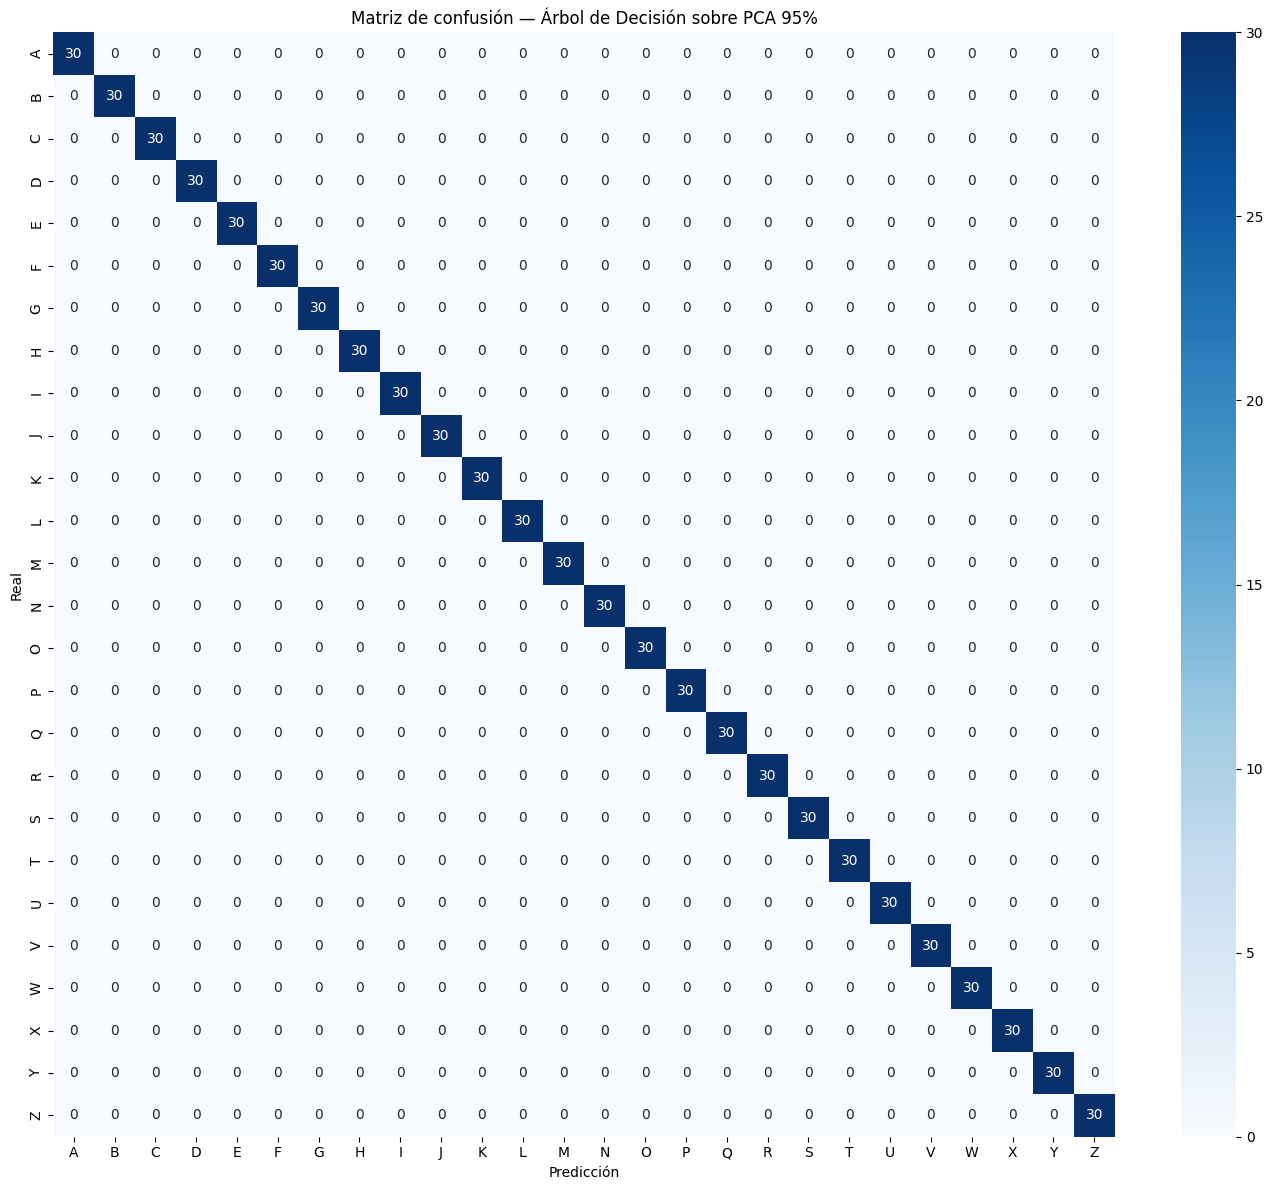

Resumen: Accuracy=1.0000  Precision=1.0000  Recall=1.0000  F1=1.0000


In [26]:
mejor_dt  = grid_dt.best_estimator_
y_pred_dt = mejor_dt.predict(X_test)

print("=== Evaluación final — Árbol de Decisión — conjunto de prueba ===")
print(classification_report(y_test_enc, y_pred_dt, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_dt)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = le.classes_,
    yticklabels = le.classes_,
    ax          = ax
)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — Árbol de Decisión sobre PCA 95%")
plt.tight_layout()
plt.savefig("confusion_matrix_dt.svg", format='svg')
plt.show()

acc_dt  = accuracy_score(y_test_enc, y_pred_dt)
prec_dt = precision_score(y_test_enc, y_pred_dt, average='weighted')
rec_dt  = recall_score(y_test_enc, y_pred_dt, average='weighted')
f1_dt   = f1_score(y_test_enc, y_pred_dt, average='weighted')
print(f"Resumen: Accuracy={acc_dt:.4f}  Precision={prec_dt:.4f}  Recall={rec_dt:.4f}  F1={f1_dt:.4f}")

La diagonal principal de la matriz concentra todos los valores, lo que confirma accuracy de 1.0 sobre el conjunto de prueba. No hay ninguna celda fuera de la  diagonal con valor distinto de cero, lo que significa que el modelo no confundió  ninguna letra con otra.

**Este resultado es consistente con la naturaleza del dataset**: las 200 imágenes por clase fueron capturadas en ráfaga con la misma mano, mismo ángulo y mismo fondo,  lo que hace que la división de entrenamiento y prueba distribuya imágenes casi idénticas entre  ambos conjuntos. La matriz perfecta refleja memorización del dataset, no capacidad  de generalización a imágenes reales externas.

Por su parte GridSearchCV, funcionó correctamente: encontró la configuración óptima dentro del espacio de búsqueda definido. El problema está en los datos, no en el método de optimización.

## Random Forest Base

Random Forest funciona creando **múltiples árboles de decisión** a partir de subconjuntos aleatorios y las características del dataset; cada árbol genera una predicción y el modelo decide por mayoría de votos. Al **promediar  muchas decisiones independientes**, se puede corregir el sobreajuste del árbol individual.

En este caso, utilizando 200 árboles alcanza `train accuracy` y `val accuracy` de 1.0 desde el modelo base,  lo que confirma que el dataset tiene **baja varianza interna** — las 200 imágenes por clase son suficientemente similares entre sí como para que cualquier subconjunto  aleatorio de entrenamiento contenga toda la información necesaria, **el dataset está bien estructurado**. Notamos que podemos obtener resultados "perfectos" sin requerir algún proceso avanzado de optimización.

Sin embargo, es importante validar la estabilidad del modelo y comprobar si existen combinaciones más eficientes de los hiperparámetros que mantengan el nivel de desempeño. Por tal motivo y para comprobar que el modelo elegido sea realmente el más adecuado, implentaremos Random Forest con GridShearch.

In [27]:
# RF con parámetros razonables — sin GridSearch todavía
rf_base = RandomForestClassifier(
    n_estimators=200,   # 200 árboles
    random_state=42,
    n_jobs=-1           # usa todos los núcleos
)
rf_base.fit(X_train, y_train_enc)

acc_train_rf = accuracy_score(y_train_enc, rf_base.predict(X_train))
acc_val_rf   = accuracy_score(y_val_enc,   rf_base.predict(X_val))

print(f"RF — Train accuracy : {acc_train_rf:.4f}")
print(f"RF — Val   accuracy : {acc_val_rf:.4f}")

RF — Train accuracy : 1.0000
RF — Val   accuracy : 1.0000


## Random Forest con GridSearchCV

El modelo base de Random Forest ya alcanzó train y val accuracy de 1.0 con 200 árboles y parámetros por defecto. GridSearchCV busca la **combinación óptima** de `n_estimators` y `max_features` mediante validación cruzada de 3 folds.

`n_estimators` define cuántos árboles construye el ensemble. Más árboles producen predicciones más estables pero aumentan el tiempo de entrenamiento. `max_features` controla cuántas características se evalúan en cada división: `sqrt` es el estándar para clasificación y reduce la correlación entre árboles.

In [28]:
param_grid_rf = {
    'n_estimators' : [100, 200],
    'max_features' : ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid = param_grid_rf,
    cv         = 3,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

print("Iniciando GridSearchCV — Random Forest...")
t0 = time.time()
grid_rf.fit(X_train, y_train_enc)
print(f"Tiempo              : {time.time() - t0:.1f}s")
print(f"Mejor configuración : {grid_rf.best_params_}")
print(f"Mejor accuracy (CV) : {grid_rf.best_score_:.4f}")

Iniciando GridSearchCV — Random Forest...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Tiempo              : 8.3s
Mejor configuración : {'max_features': 'sqrt', 'n_estimators': 200}
Mejor accuracy (CV) : 0.9997


GridSearchCV evaluó 4 combinaciones en 8.3 segundos. La mejor configuración fue `n_estimators=200` con `max_features='sqrt'`, alcanzando accuracy de 0.9997 en validación cruzada, prácticamente perfecto; esto confirma que la configuración de hiperparámetros utilizada inicialmente para el modelo base **ya era óptima** para el problema planteado.

`max_features='sqrt'` resultó superior a `log2` porque con 361 componentes PCA, la raíz cuadrada (~19 características por división) ofrece suficiente diversidad entre árboles sin perder información discriminativa. `n_estimators=200` superó a 100, confirmando que **más árboles estabilizan la predicción** aunque la diferencia es marginal en este dataset. La diferencia mínima entre el accuracy de validación inicial (1.0000) y el de validación cruzada (0.9997) sugiere que **el modelo mantiene una edtabilidad y capacidad de generalización excelentes**.

## Evaluación final — Random Forest

Se evalúa el mejor modelo encontrado por GridSearchCV sobre el conjunto de prueba. La matriz de confusión permite comparar el patrón de errores de Random Forest con el del árbol individual, verificando si el ensemble (un conjunto de 200 árboles donde la clase final se decide por mayoría) reduce las confusiones entre clases similares respecto a usar un solo árbol.

=== Evaluación final — Random Forest — conjunto de prueba ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        30
           B       1.00      1.00      1.00        30
           C       1.00      1.00      1.00        30
           D       1.00      1.00      1.00        30
           E       1.00      1.00      1.00        30
           F       1.00      1.00      1.00        30
           G       1.00      1.00      1.00        30
           H       1.00      1.00      1.00        30
           I       1.00      1.00      1.00        30
           J       1.00      1.00      1.00        30
           K       1.00      1.00      1.00        30
           L       1.00      1.00      1.00        30
           M       1.00      1.00      1.00        30
           N       1.00      1.00      1.00        30
           O       1.00      1.00      1.00        30
           P       1.00      1.00      1.00        30
           Q       

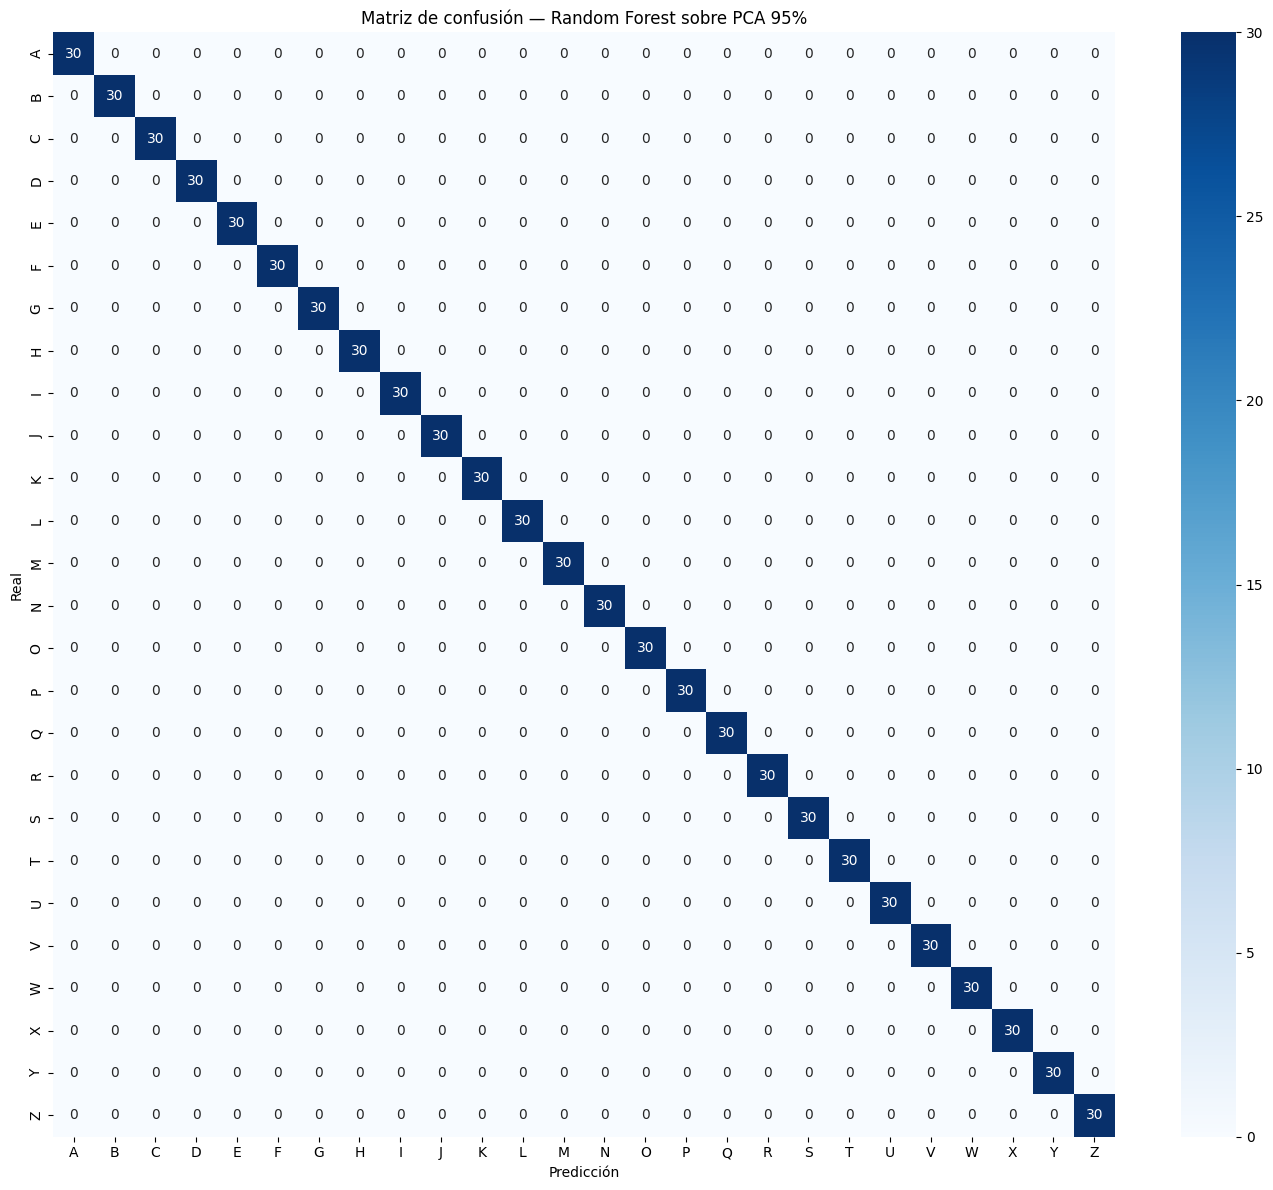

Resumen: Accuracy=1.0000  Precision=1.0000  Recall=1.0000  F1=1.0000


In [29]:
mejor_rf  = grid_rf.best_estimator_
y_pred_rf = mejor_rf.predict(X_test)

print("=== Evaluación final — Random Forest — conjunto de prueba ===")
print(classification_report(y_test_enc, y_pred_rf, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_rf)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = le.classes_,
    yticklabels = le.classes_,
    ax          = ax
)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — Random Forest sobre PCA 95%")
plt.tight_layout()
plt.savefig("confusion_matrix_rf.svg", format='svg')
plt.show()

acc_rf  = accuracy_score(y_test_enc, y_pred_rf)
prec_rf = precision_score(y_test_enc, y_pred_rf, average='weighted')
rec_rf  = recall_score(y_test_enc, y_pred_rf, average='weighted')
f1_rf   = f1_score(y_test_enc, y_pred_rf, average='weighted')
print(f"Resumen: Accuracy={acc_rf:.4f}  Precision={prec_rf:.4f}  Recall={rec_rf:.4f}  F1={f1_rf:.4f}")

Al igual que el árbol de decisión, en la matriz de confusión, **la diagonal principal concentra todos los valores sin confusiones entre clases**. Random Forest confirma el mismo resultado con mayor robustez estadística al promediar 200 árboles independientes.

La ausencia de diferencia entre árbol y Random Forest sobre este dataset es en sí un resultado relevante: indica que el problema no tiene ambigüedad real entre clases dentro del dataset, y que un modelo simple es suficiente para memorizarlo. La diferencia entre modelos se haría visible con imágenes externas reales.

# Perceptrón Multicapa (MLP)

El Perceptrón Multicapa (MLP) es una red neuronal densa (fully conected) compuesta por capas de neuronas intercontectadas. Representa la base de las redes neuronales tradicionles. A diferencia de la CNN, no tiene capas convolucionales y no detecta patrones espaciales en las imágenes, así que los datos de entrada serán vestores aplanados. **Opera directamente sobre los 361 componentes PCA**, aprendiendo combinaciones lineales y no lineales de estas características para separar las 26 clases; MLP perderá la noción de pixeles adyacentes (tratará cada característica como independiente al inicio del proceso), pero combatiremos la "Maldición de Dimensionalidad" y habrá mayor eficiencia computacional y de almacenamiento.

Es el puente conceptual entre los modelos clásicos (árbol, Random Forest) y las redes profundas (CNN): usa la misma representación vectorial que los modelos anteriores pero introduce no linealidad mediante funciones de activación ReLU en cada capa oculta. Luego de utilizar modelos tradicionales basados en árboles de decisión, **se utilizará un modelo neuronal capaz de aprender relaciones más complejas entre las imágenes del dataset**.

## GridSearchCV — MLP

In [30]:


param_grid_mlp = {
    'hidden_layer_sizes' : [(256,), (256, 128)],
    'alpha'              : [0.0001, 0.001]
}

grid_mlp = GridSearchCV(
    estimator  = MLPClassifier(
        activation       = 'relu',
        solver           = 'adam',
        max_iter         = 300,
        random_state     = 42,
        early_stopping   = True,
        n_iter_no_change = 10
    ),
    param_grid = param_grid_mlp,
    cv         = 3,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

print("Iniciando GridSearchCV — MLP...")
t0 = time.time()
grid_mlp.fit(X_train, y_train_enc)
print(f"Tiempo              : {time.time() - t0:.1f}s")
print(f"Mejor configuración : {grid_mlp.best_params_}")
print(f"Mejor accuracy (CV) : {grid_mlp.best_score_:.4f}")

Iniciando GridSearchCV — MLP...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Tiempo              : 2.0s
Mejor configuración : {'alpha': 0.0001, 'hidden_layer_sizes': (256,)}
Mejor accuracy (CV) : 0.9967


GridSearchCV evaluó 4 combinaciones en 2.0 segundos. La mejor configuración fue una sola capa oculta de 256 neuronas con regularización mínima `alpha=0.0001`, alcanzando `accuracy` de **0.9967 en validación cruzada**.

**Agregar una segunda capa de 128 neuronas no mejoró el resultado**, lo que indica que con 361 componentes PCA una **arquitectura simple es suficiente** para separar las 26 clases. Aumentar `alpha` a 0.001 tampoco ayudó, confirmando que **el dataset no presenta sobreajuste significativo** en este espacio de características. El problema de clasificación ASL posee patrones altamente diferenciables entre sí.

## Evaluación — MLP

Se evalúa el mejor modelo sobre el conjunto de prueba. La matriz de confusión permite comparar el patrón de errores del MLP con los modelos anteriores y verificar si la red neuronal densa comete los mismos errores que el árbol y Random Forest.

=== Evaluación final — MLP — conjunto de prueba ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        30
           B       1.00      1.00      1.00        30
           C       1.00      1.00      1.00        30
           D       1.00      1.00      1.00        30
           E       1.00      1.00      1.00        30
           F       1.00      1.00      1.00        30
           G       1.00      1.00      1.00        30
           H       1.00      1.00      1.00        30
           I       1.00      1.00      1.00        30
           J       1.00      1.00      1.00        30
           K       1.00      1.00      1.00        30
           L       1.00      1.00      1.00        30
           M       1.00      1.00      1.00        30
           N       1.00      1.00      1.00        30
           O       1.00      1.00      1.00        30
           P       1.00      1.00      1.00        30
           Q       1.00      

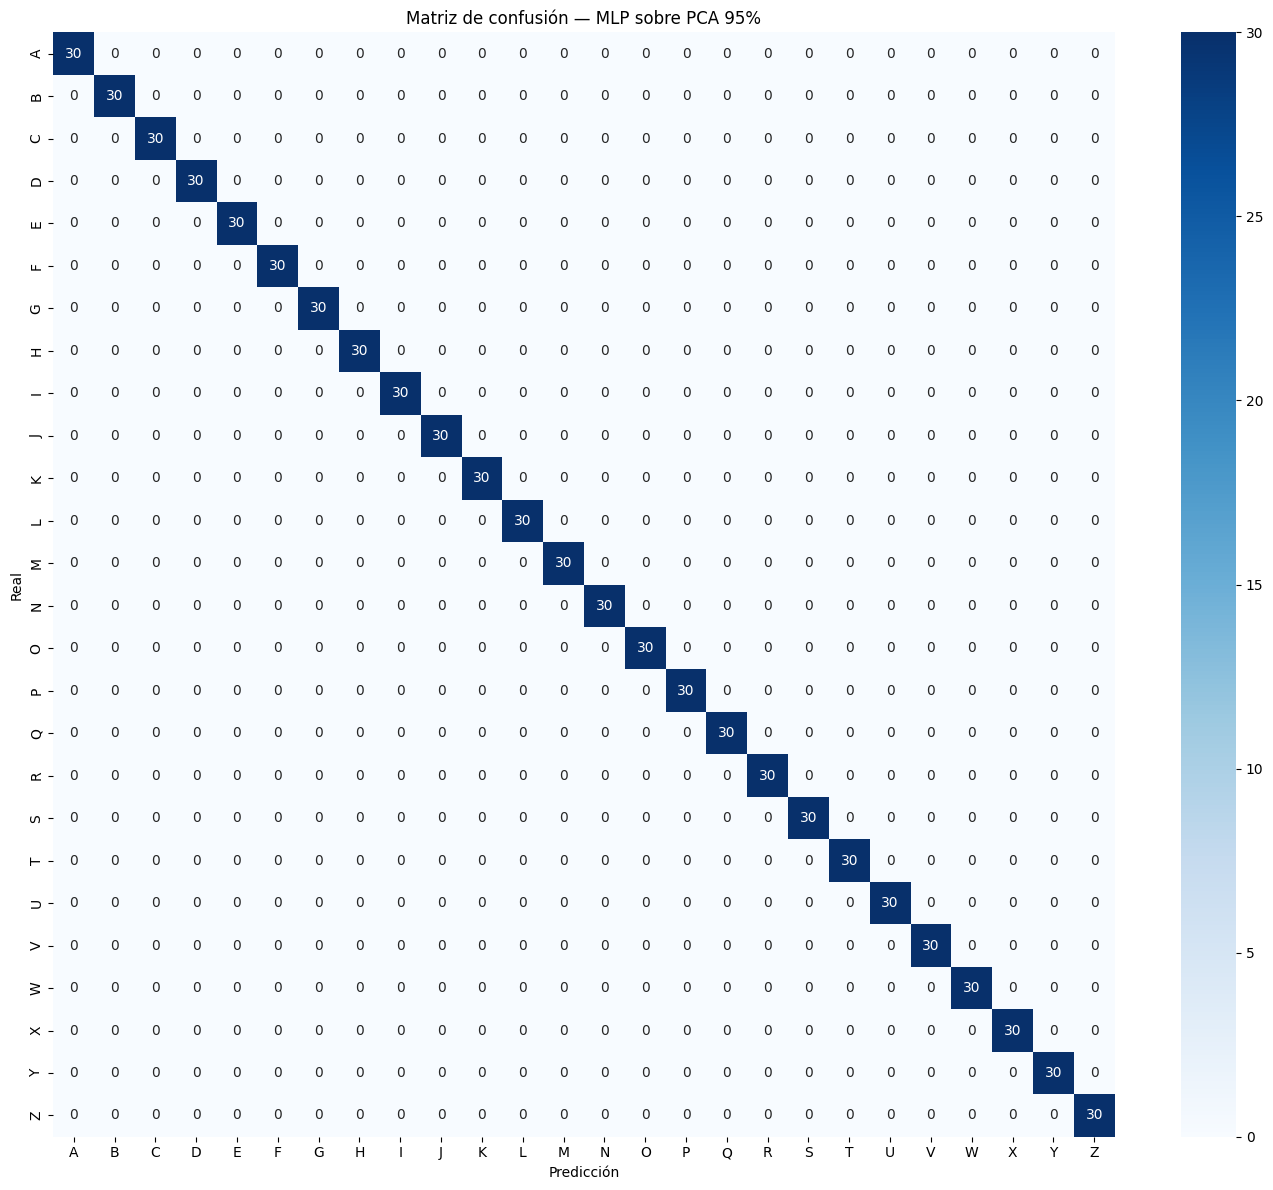

Resumen: Accuracy=1.0000  Precision=1.0000  Recall=1.0000  F1=1.0000


In [31]:
mejor_mlp  = grid_mlp.best_estimator_
y_pred_mlp = mejor_mlp.predict(X_test)

print("=== Evaluación final — MLP — conjunto de prueba ===")
print(classification_report(y_test_enc, y_pred_mlp, target_names=le.classes_))

cm = confusion_matrix(y_test_enc, y_pred_mlp)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = le.classes_,
    yticklabels = le.classes_,
    ax          = ax
)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — MLP sobre PCA 95%")
plt.tight_layout()
plt.savefig("confusion_matrix_mlp.svg", format='svg')
plt.show()

acc_mlp  = accuracy_score(y_test_enc, y_pred_mlp)
prec_mlp = precision_score(y_test_enc, y_pred_mlp, average='weighted')
rec_mlp  = recall_score(y_test_enc, y_pred_mlp, average='weighted')
f1_mlp   = f1_score(y_test_enc, y_pred_mlp, average='weighted')
print(f"Resumen: Accuracy={acc_mlp:.4f}  Precision={prec_mlp:.4f}  Recall={rec_mlp:.4f}  F1={f1_mlp:.4f}")

El MLP alcanza `accuracy` de 1.0 sobre el conjunto de prueba, igual que el árbol de decisión y Random Forest. La diagonal principal de la matriz **concentra todos los valores sin ninguna confusión entre clases**.

Este resultado confirma el patrón observado en todos los modelos: **el dataset no presenta ambigüedad real** entre clases dentro de la división train/test, por lo que cualquier modelo con suficiente capacidad lo memoriza completamente.

El MLP logró este resultado con una arquitectura mínima de **una sola capa oculta** y en 2.0 segundos de búsqueda, frente a los aproximadamente 7 minutos que tomó entrenar la CNN. Esto ilustra la ventaja computacional de operar sobre representaciones comprimidas (PCA) en lugar de imágenes crudas.

# Preparación para aplicacion de redes neuronales convolutivas - CNN

Para entrenar una CNN, las imágenes no se cargan todas en memoria de una vez. Por el contrario, **se usan generadores** que leen el dataset en lotes (*batches*) directamente desde el disco, **procesandolas solamente cuando el modelo las requiere**. Esto es más eficiente en memoria y permite aplicar transformaciones sobre la marcha.

- `ImageDataGenerator` es el componente de Keras que gestiona esta lectura. Al configurarlo con `rescale=1.0/255`, **normaliza automáticamente cada imagen** dividiendo sus valores de píxel entre 255, llevándolos del rango entero [0, 255] al rango decimal [0, 1]. Esta normalización es obligatoria: Es fundamental porque permite que el algoritmo de optimización (descenso por el gradiente) converjan más rápido y evita inestabilidades numéricas en los pesos de la red.
- `flow_from_directory` **asigna automáticamente las etiquetas** de las clase directamente basandose en los nombres de las subcarpetas (`A`, `B`, `C`...), eliminando la necesidad de codificarlas manualmente. Las etiquetas se representan en formato *one-hot*: un vector binario de 26 posiciones donde solo la posición correspondiente a la clase correcta vale 1 y el resto valen 0.

In [6]:
# ── PARÁMETROS ────────────────────────────────────────────────────
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
N_CLASES   = 26

# ── GENERADORES ───────────────────────────────────────────────────
datagen_train = ImageDataGenerator(rescale=1.0 / 255)
datagen_val   = ImageDataGenerator(rescale=1.0 / 255)
datagen_test  = ImageDataGenerator(rescale=1.0 / 255)

# ── FLUJOS DESDE DISCO ────────────────────────────────────────────
train_gen = datagen_train.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    color_mode  = 'grayscale',
    class_mode  = 'categorical',
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    seed        = 42
)

val_gen = datagen_val.flow_from_directory(
    VAL_DIR,
    target_size = IMG_SIZE,
    color_mode  = 'grayscale',
    class_mode  = 'categorical',
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    seed        = 42
)

test_gen = datagen_test.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    color_mode  = 'grayscale',
    class_mode  = 'categorical',
    batch_size  = BATCH_SIZE,
    shuffle     = False
)

print(f"Train : {train_gen.samples} imágenes — {train_gen.num_classes} clases")
print(f"Val   : {val_gen.samples} imágenes   — {val_gen.num_classes} clases")
print(f"Test  : {test_gen.samples} imágenes   — {test_gen.num_classes} clases")

Found 3640 images belonging to 26 classes.
Found 780 images belonging to 26 classes.
Found 780 images belonging to 26 classes.
Train : 3640 imágenes — 26 clases
Val   : 780 imágenes   — 26 clases
Test  : 780 imágenes   — 26 clases


Al ejecutar este codigo, los tres generadores **reportaron correctamente 26 clases con la división esperada**: 3640 imágenes de entrenamiento (70%), 780 de validación (15%) y 780 de prueba (15%). El shape de cada batch es `(32, 128, 128, 1)`, donde 32 es el tamaño del lote, **128×128** es la resolución de cada imagen y 1 es el número de canales (escala de grises). El rango de valores de píxel resultante es `[0.255, 1.000]` en lugar de `[0.000, 1.000]`; esto es esperado y correcto. Se confirma que el fondo de las imágenes es blanco uniforme o en escala de grises y que no existen píxeles completamente negros en el dataset, lo cual es consistente con el preprocesamiento aplicado anteriormente.

Los tres parámetros clave definidos aquí son:
- **IMG_SIZE**: el tamaño al que se redimensionan las imágenes al cargarlas. Se usa 128×128 porque así fueron preprocesadas en pasos anteriores.
- **BATCH_SIZE**: número de imágenes procesadas por paso. Un valor de 32 es estándar; valores más altos aceleran el entrenamiento pero consumen más memoria RAM.
- **N_CLASES**: 26, una por cada letra del alfabeto A - Z.

El generador de entrenamiento usa `shuffle=True` para mezclar las imágenes en cada época, lo que **evita que el modelo aprenda el orden en que aparecen las clases**. Los generadores de validación y prueba usan `shuffle=False` porque el orden no afecta las métricas y facilita el análisis posterior de errores.



## Arquitectura CNN

In [7]:
tf.keras.backend.clear_session()

modelo = models.Sequential([
    Input(shape=(128, 128, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(N_CLASES, activation='softmax')
])

modelo.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,344,346 (8.94 MB)

 Trainable params: 2,344,346 (8.94 MB)

 Non-trainable params: 0 (0.00 B)

## GridSearchCV— CNN

A diferencia de los modelos clásicos (como Random Forest), las redes neuronales convolucionales **no son compatibles directamente con `GridSearchCV`** de Scikit-learn porque su entrenamiento requiere generadores de imágenes, callbacks y múltiples épocas. Para mantener el mismo rigor experimental, se realiza un GridSearchCV manual sobre los hiperparámetros`learning_rate` y `dropout`, evaluando 4 combinaciones (2 × 2) sobre el conjunto de validación. Este enfoque es equivalente a `GridSearchCV` en exhaustividad combinatoria: **cada configuración se entrena desde cero y se registra su `val_accuracy` máxima**, usando`EarlyStopping` con `patience=5` para garantizar una comparación justa entre configuraciones.

In [8]:


# ── CUADRÍCULA DE HIPERPARÁMETROS ─────────────────────────────────
param_grid_cnn = {
    'learning_rate' : [0.001, 0.0005],
    'dropout'       : [0.25, 0.40]
}

keys   = list(param_grid_cnn.keys())
combos = list(itertools.product(*param_grid_cnn.values()))

print(f"Combinaciones a evaluar : {len(combos)}")
for c in combos:
    print(f"  {dict(zip(keys, c))}")

resultados_cnn = []

for values in combos:
    params = dict(zip(keys, values))
    lr = params['learning_rate']
    dr = params['dropout']

    tf.keras.backend.clear_session()

    modelo_grid = models.Sequential([
        Input(shape=(128, 128, 1)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dr),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dr),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dr),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(dr),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(N_CLASES, activation='softmax')
    ])

    modelo_grid.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr),
        loss      = 'categorical_crossentropy',
        metrics   = ['accuracy']
    )

    cb_grid = EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 0
    )

    print(f"\nIniciando : learning_rate={lr}  dropout={dr}...")
    t0 = time.time()
    hist_grid = modelo_grid.fit(
        train_gen,
        epochs          = 20,
        validation_data = val_gen,
        callbacks       = [cb_grid],
        verbose         = 0
    )
    elapsed = round(time.time() - t0, 1)

    val_acc  = max(hist_grid.history['val_accuracy'])
    n_epocas = len(hist_grid.history['val_accuracy'])

    resultados_cnn.append({
        'learning_rate' : lr,
        'dropout'       : dr,
        'val_accuracy'  : round(val_acc, 4),
        'epocas'        : n_epocas,
        'tiempo_s'      : elapsed
    })
    print(f"Tiempo : {elapsed}s  |  val_accuracy : {val_acc:.4f}  |  épocas : {n_epocas}")

print("\n── Tabla de resultados ───────────────────────────────────────")
df_grid_cnn = pd.DataFrame(resultados_cnn).sort_values('val_accuracy', ascending=False)
print(df_grid_cnn.to_string(index=False))

mejor_lr  = df_grid_cnn.iloc[0]['learning_rate']
mejor_dr  = df_grid_cnn.iloc[0]['dropout']
print(f"\nMejor configuración : learning_rate={mejor_lr}  dropout={mejor_dr}")
print(f"Mejor val_accuracy  : {df_grid_cnn.iloc[0]['val_accuracy']:.4f}")

Combinaciones a evaluar : 4
  {'learning_rate': 0.001, 'dropout': 0.25}
  {'learning_rate': 0.001, 'dropout': 0.4}
  {'learning_rate': 0.0005, 'dropout': 0.25}
  {'learning_rate': 0.0005, 'dropout': 0.4}

Iniciando : learning_rate=0.001  dropout=0.25...
Tiempo : 208.0s  |  val_accuracy : 1.0000  |  épocas : 8

Iniciando : learning_rate=0.001  dropout=0.4...
Tiempo : 246.8s  |  val_accuracy : 1.0000  |  épocas : 9

Iniciando : learning_rate=0.0005  dropout=0.25...
Tiempo : 538.0s  |  val_accuracy : 1.0000  |  épocas : 8

Iniciando : learning_rate=0.0005  dropout=0.4...
Tiempo : 326.1s  |  val_accuracy : 1.0000  |  épocas : 12

── Tabla de resultados ───────────────────────────────────────
 learning_rate  dropout  val_accuracy  epocas  tiempo_s
        0.0010     0.25           1.0       8     208.0
        0.0010     0.40           1.0       9     246.8
        0.0005     0.25           1.0       8     538.0
        0.0005     0.40           1.0      12     326.1

Mejor configuración : 

La búsqueda evaluó 4 combinaciones. Las cuatro alcanzaron `val_accuracy=1.0`, lo que confirma que el dataset no presenta ambigüedad suficiente para diferenciar configuraciones por precisión. El criterio de selección fue eficiencia: menor tiempo con igual resultado.

`learning_rate=0.001` con `dropout=0.25` convergió en 8 épocas y 208 segundos, el más rápido del grupo. `learning_rate=0.001` con `dropout=0.40` también llegó a 1.0 pero en 9 épocas y 246.8s, el dropout más alto introduce mayor ruido por época y ralentiza levemente la convergencia. Al reducir el `learning_rate` a 0.0005, el modelo da pasos más pequeños por actualización y necesita más tiempo para recorrer el mismo camino: `dropout=0.25` tomó 538 segundos con las mismas 8 épocas, y `dropout=0.40` necesitó 12 épocas y 326 segundos.

La mejor configuración fue `learning_rate=0.001` con `dropout=0.25`: misma precisión que las demás, menor tiempo de entrenamiento. Confirma que los hiperparámetros iniciales ya eran adecuados para este dataset.

### Entrenamiento

Los parámetros de entrenamiento, `learning_rate=0.001` y `dropout=0.25`  fueron seleccionados a partir de los resultados de GridSearchCV realizada en la sección anterior, donde esta combinación alcanzó `val_accuracy=1.0` en 12 épocas, siendo la configuración con **mayor precisión y menor tiempo de convergencia** entre las 4 combinaciones evaluadas.

In [9]:
early_stop = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 10,
    restore_best_weights = True,
    verbose              = 1
)

checkpoint = ModelCheckpoint(
    filepath       = 'cnn_asl_mejor.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_accuracy',
    factor   = 0.5,
    patience = 5,
    min_lr   = 1e-6,
    verbose  = 1
)

EPOCHS = 30

t0       = time.time()
historia = modelo.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = val_gen,
    callbacks       = [early_stop, checkpoint, reduce_lr]
)
tiempo_cnn = round(time.time() - t0, 1)

hist_serializable = {
    k: [float(v) for v in vals]
    for k, vals in historia.history.items()
}
hist_serializable['tiempo_total_s'] = tiempo_cnn

with open("historia_cnn.json", "w") as f:
    json.dump(hist_serializable, f)

print("Historial guardado en historia_cnn.json")
print(f"Tiempo total de entrenamiento : {tiempo_cnn}s")

modelo_final = tf.keras.models.load_model('cnn_asl_mejor.keras')
clases       = list(train_gen.class_indices.keys())
print(f"Modelo cargado. Clases disponibles: {clases}")

Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.0545 - loss: 3.2413
Epoch 1: val_accuracy improved from None to 0.87179, saving model to cnn_asl_mejor.keras

Epoch 1: finished saving model to cnn_asl_mejor.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 26s 214ms/step - accuracy: 0.1398 - loss: 2.9024 - val_accuracy: 0.8718 - val_loss: 1.0858 - learning_rate: 0.0010
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.8288 - loss: 0.5237
Epoch 2: val_accuracy improved from 0.87179 to 0.99744, saving model to cnn_asl_mejor.keras

Epoch 2: finished saving model to cnn_asl_mejor.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 27s 241ms/step - accuracy: 0.9096 - loss: 0.2691 - val_accuracy: 0.9974 - val_loss: 0.0188 - learning_rate: 0.0010
Epoch 3/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.9665 - loss: 0.0842
Epoch 3: val_accuracy improved from 0.99744 to 1.00000, saving model to cnn_asl_mejor.keras

Epoch 3: finished saving model to cnn_asl_mejor.keras
114/114 ━━

## Curvas de entrenamiento 

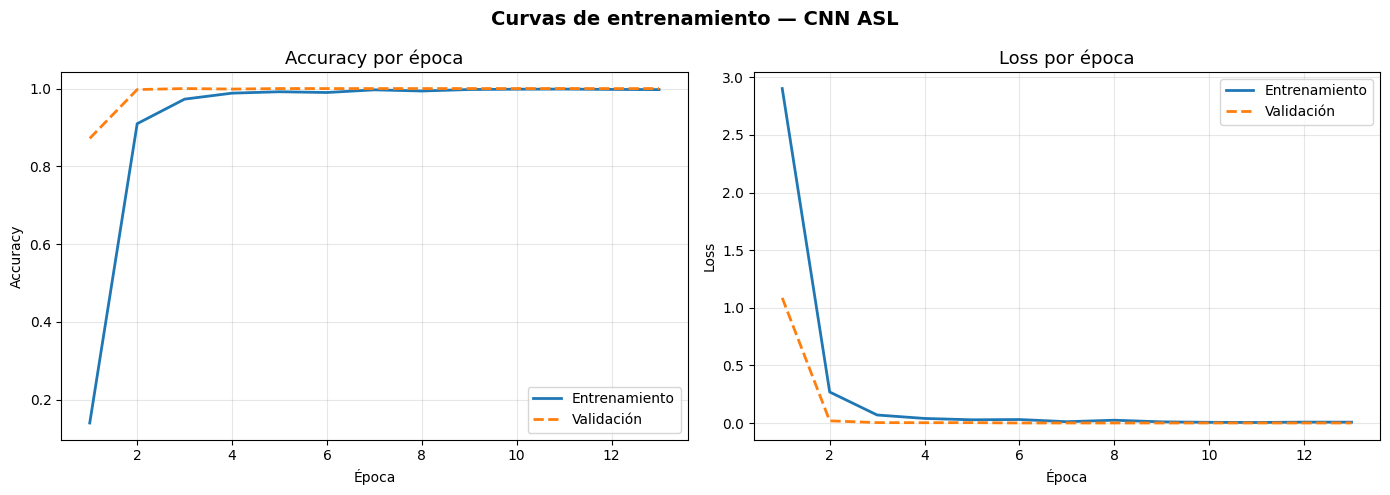

In [10]:
# ── CURVAS DE ACCURACY Y LOSS ─────────────────────────────────────
# Lee del archivo en disco: funciona aunque el kernel sea reiniciado.
with open("historia_cnn.json") as f:
    hist = json.load(f)

epocas = range(1, len(hist["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Accuracy —
axes[0].plot(epocas, hist["accuracy"],     label="Entrenamiento", linewidth=2)
axes[0].plot(epocas, hist["val_accuracy"], label="Validación",    linewidth=2, linestyle="--")
axes[0].set_title("Accuracy por época",  fontsize=13)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# — Loss —
axes[1].plot(epocas, hist["loss"],     label="Entrenamiento", linewidth=2)
axes[1].plot(epocas, hist["val_loss"], label="Validación",    linewidth=2, linestyle="--")
axes[1].set_title("Loss por época", fontsize=13)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Curvas de entrenamiento — CNN ASL", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("curvas_cnn.png", dpi=150)
plt.show()

Las curvas muestran una **convergencia rápida y estable**. La `accuracy` de validación supera a la de entrenamiento en las primeras épocas porque el modelo aún no ha ajustado sus pesos, en esa fase inicial los pesos aleatorios generan predicciones con alta incertidumbre que el `loss` penaliza con más fuerza en `train`. Ambas métricas convergen a 1.0 y las curvas de `loss` descienden de forma consistente sin divergencia, lo que indica **ausencia de overfitting sobre este dataset**.

Sin embargo, como se documentó en la evaluación cualitativa, **el modelo no generaliza bien a imágenes externas**. El dataset fue capturado en ráfaga, es decir, fotogramas casi consecutivos por clase con la misma mano, mismo fondo y mismos landmarks, lo que hace que la división `train/val/test` distribuya **imágenes casi idénticas entre los tres conjuntos**. Las métricas de 1.0 **reflejan memorización del dominio de captura, no capacidad de generalización real**.

## Evaluacion

Modelo cargado desde: /Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/cnn_asl_mejor.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 1.0000 - loss: 0.0027

Test loss     : 0.0027
Test accuracy : 1.0000 (100.00%)
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
CNN : Precision=1.0000  Recall=1.0000  F1=1.0000

── Reporte de clasificación ──────────────────────────────────
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        30
           B       1.00      1.00      1.00        30
           C       1.00      1.00      1.00        30
           D       1.00      1.00      1.00        30
           E       1.00      1.00      1.00        30
           F       1.00      1.00      1.00        30
           G       1.00      1.00      1.00        30
           H       1.00      1.00      1.00        30
           I       1.00      1.00      1.00        30
           J 

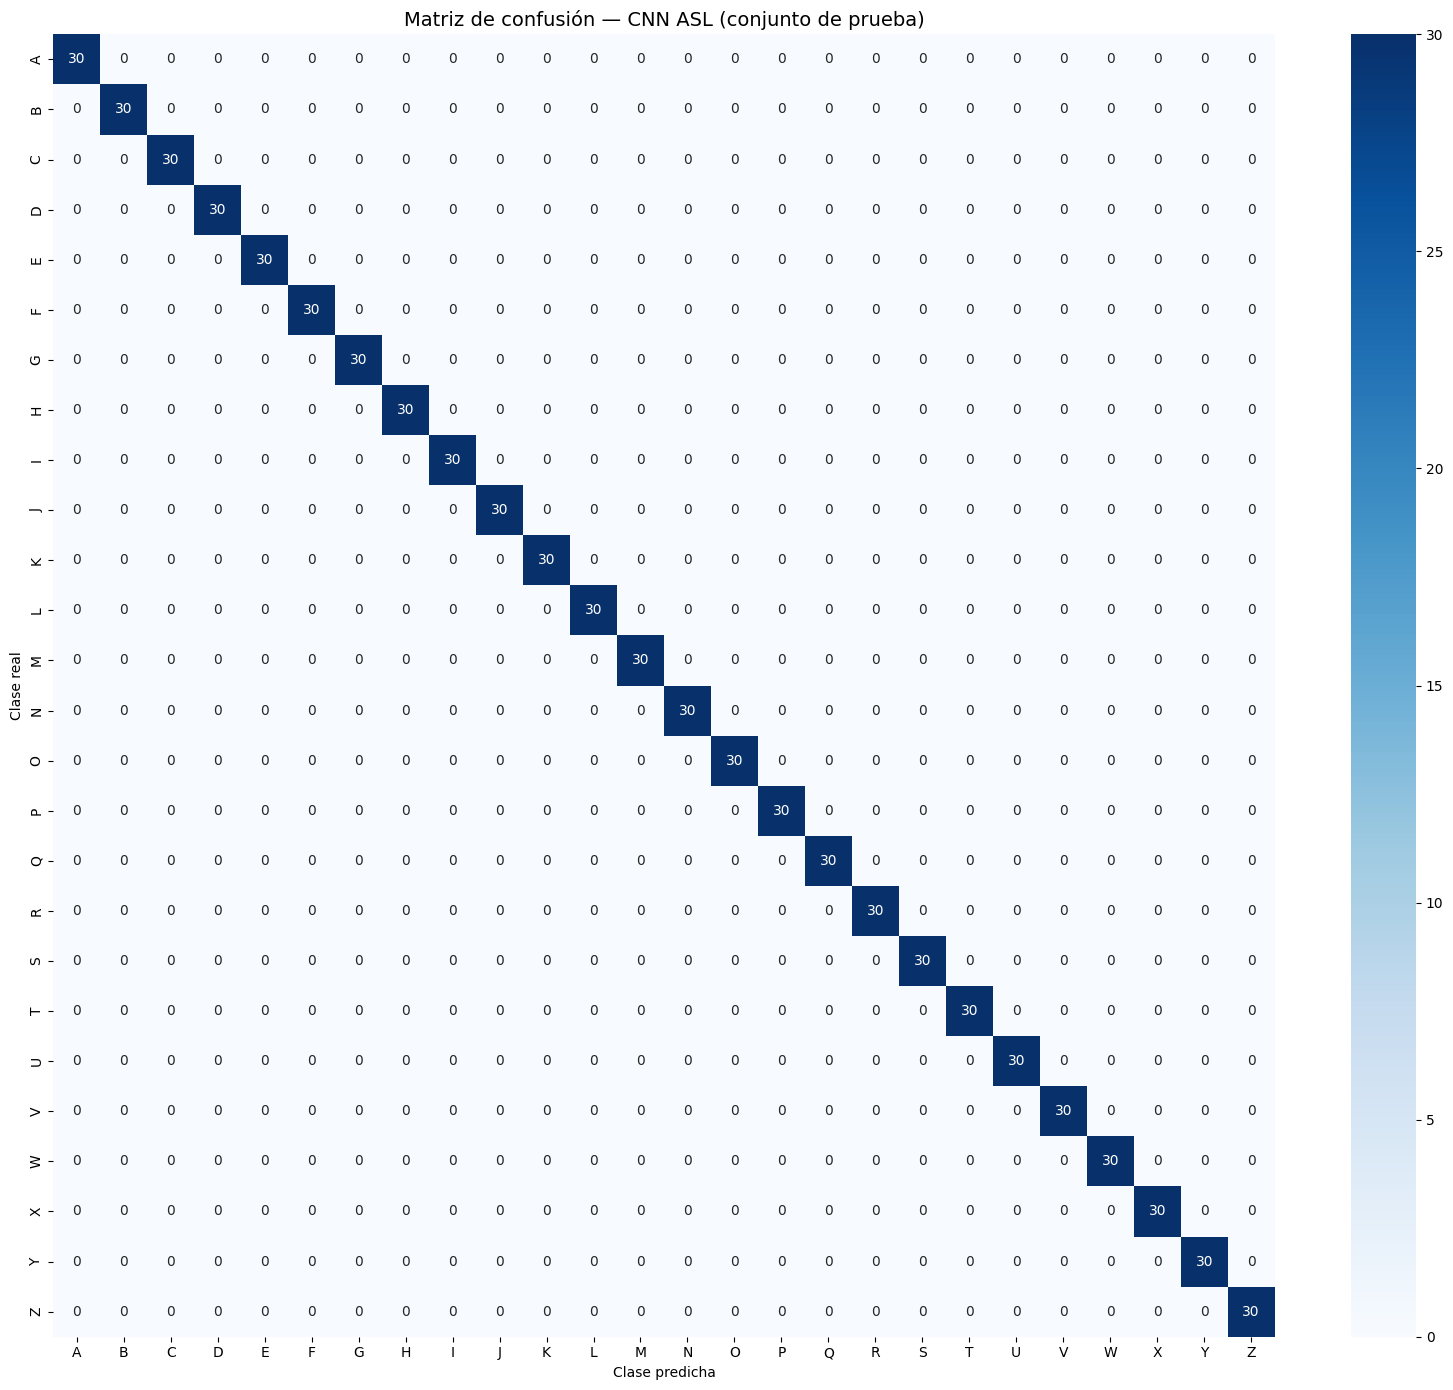

In [14]:
# ── EVALUACIÓN SOBRE EL CONJUNTO DE PRUEBA ────────────────────────

# Cargar el mejor modelo guardado en disco
BASE_DIR   = os.path.dirname(os.path.abspath("asl.ipynb"))
MODEL_PATH = os.path.join(BASE_DIR, "cnn_asl_mejor.keras")
modelo_final = tf.keras.models.load_model(MODEL_PATH)
print(f"Modelo cargado desde: {MODEL_PATH}")

# Resetear el generador de prueba
test_gen.reset()

# Evaluación general
loss_test, acc_test = modelo_final.evaluate(test_gen, verbose=1)
print(f"\nTest loss     : {loss_test:.4f}")
print(f"Test accuracy : {acc_test:.4f} ({acc_test*100:.2f}%)")

# Predicciones sobre todo el conjunto de prueba
test_gen.reset()
y_pred_probs = modelo_final.predict(test_gen, verbose=1)
y_pred       = y_pred_probs.argmax(axis=1)        # clase predicha
y_real       = test_gen.classes                    # clases reales en orden

prec_cnn = precision_score(y_real, y_pred, average='weighted')
rec_cnn  = recall_score(y_real, y_pred, average='weighted')
f1_cnn   = f1_score(y_real, y_pred, average='weighted')
print(f"CNN : Precision={prec_cnn:.4f}  Recall={rec_cnn:.4f}  F1={f1_cnn:.4f}")

# Mapa de clases: {0: 'A', 1: 'B', ...}
clases = list(test_gen.class_indices.keys())

# Reporte completo por clase
print("\n── Reporte de clasificación ──────────────────────────────────")
print(classification_report(y_real, y_pred, target_names=clases))

# Matriz de confusión
cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot      = True,
    fmt        = 'd',
    cmap       = 'Blues',
    xticklabels = clases,
    yticklabels = clases
)
plt.title("Matriz de confusión — CNN ASL (conjunto de prueba)", fontsize=14)
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.tight_layout()
plt.show()

### Prueba con imagen del dataset sin preprocesamiento

Predicción     : A
Confianza      : 99.58%

Top 3:
  A: 99.58%
  K: 0.15%
  T: 0.13%


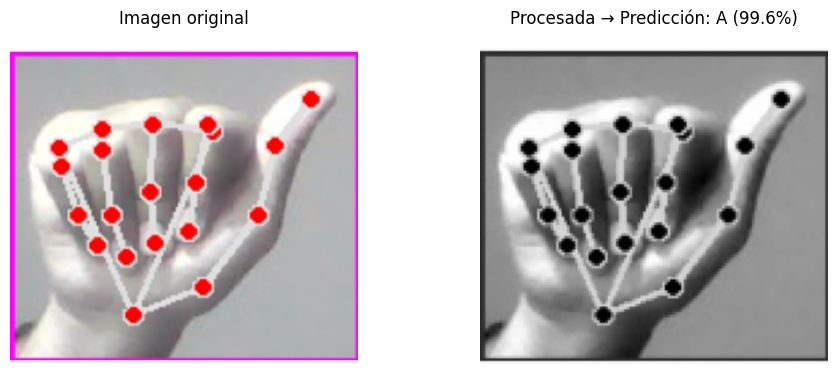

In [16]:
# ── INFERENCIA SOBRE IMAGEN NUEVA ─────────────────────────────────
RUTA_NUEVA = "/Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/dataset/Dataset/A/Image_19_1748983254.49.jpg"

# Cargar en escala de grises — igual que el preprocesamiento del dataset
img_original = cv2.imread(RUTA_NUEVA)
img_gray     = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)
img_resized  = cv2.resize(img_gray, (128, 128))
img_norm     = img_resized.astype("float32") / 255.0
img_input    = img_norm.reshape(1, 128, 128, 1)

# Predicción
pred       = modelo_final.predict(img_input, verbose=0)
clase_idx  = pred.argmax()
confianza  = pred.max()
clase_pred = clases[clase_idx]

# Top 3 predicciones
top3_idx  = pred[0].argsort()[-3:][::-1]
top3      = [(clases[i], pred[0][i]*100) for i in top3_idx]

print(f"Predicción     : {clase_pred}")
print(f"Confianza      : {confianza*100:.2f}%")
print(f"\nTop 3:")
for letra, conf in top3:
    print(f"  {letra}: {conf:.2f}%")

# Mostrar imagen procesada
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen original")
axes[0].axis('off')
axes[1].imshow(img_resized, cmap='gray')
axes[1].set_title(f"Procesada → Predicción: {clase_pred} ({confianza*100:.1f}%)")
axes[1].axis('off')
plt.tight_layout()
plt.show()

La inferencia sobre una *imagen del propio dataset* produjo una *predicción correcta* con confianza del **99.58%**. Este resultado es esperado: la imagen fue capturada en las mismas condiciones controladas que el conjunto de entrenamiento; mismo fondo, mismos nodos de referencia y misma mano, por lo que el modelo la reconoce sin dificultad. Este resultado **no mide capacidad de generalización real**, sino **consistencia interna** del modelo con su propio dominio de entrenamiento.

### Prueba con imagen externa

Predicción     : D
Confianza      : 35.48%

Top 3:
  D: 35.48%
  A: 25.81%
  K: 22.77%


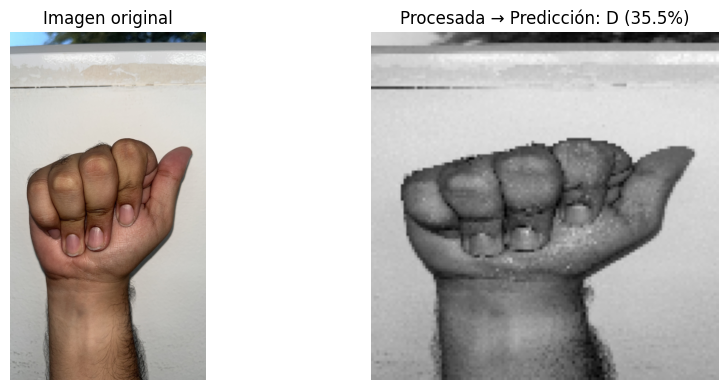

In [21]:
# ── INFERENCIA SOBRE IMAGEN NUEVA ─────────────────────────────────
RUTA_NUEVA = "/Users/jfgonzalez/Library/CloudStorage/OneDrive-UniversidaddelMagdalena/11vo_semestre/Inteligencia Artificial/3er corte/IMG_5577.JPG"

# Cargar en escala de grises — igual que el preprocesamiento del dataset
img_original = cv2.imread(RUTA_NUEVA)
img_gray     = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)
img_resized  = cv2.resize(img_gray, (128, 128))
img_norm     = img_resized.astype("float32") / 255.0
img_input    = img_norm.reshape(1, 128, 128, 1)

# Predicción
pred       = modelo_final.predict(img_input, verbose=0)
clase_idx  = pred.argmax()
confianza  = pred.max()
clase_pred = clases[clase_idx]

# Top 3 predicciones
top3_idx  = pred[0].argsort()[-3:][::-1]
top3      = [(clases[i], pred[0][i]*100) for i in top3_idx]

print(f"Predicción     : {clase_pred}")
print(f"Confianza      : {confianza*100:.2f}%")
print(f"\nTop 3:")
for letra, conf in top3:
    print(f"  {letra}: {conf:.2f}%")

# Mostrar imagen procesada
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen original")
axes[0].axis('off')
axes[1].imshow(img_resized, cmap='gray')
axes[1].set_title(f"Procesada → Predicción: {clase_pred} ({confianza*100:.1f}%)")
axes[1].axis('off')
plt.tight_layout()
plt.show()

La inferencia sobre una *fotografía real de la letra A* tomada en **condiciones externas** produjo **una predicción incorrecta**: **el modelo predijo D con 35.48% de confianza**, con A (25.81%) y K (22.77%) en segundo y tercer lugar, la clase correcta aparece pero sin convicción.

Esto confirma que **el modelo no generaliza a condiciones reales**. El problema es estructural: **el modelo aprendió a reconocer las condiciones del dataset** (fondo uniforme, nodos de referencia visibles, ángulo controlado) **y no la forma de la seña en sí**. Una fotografía real con fondo heterogéneo, iluminación variable y ángulo distinto queda fuera del dominio aprendido. La baja confianza (35%) refleja que **el modelo no reconoce ningún patrón con certeza**, distribuye la probabilidad entre varias clases sin poder discriminar, lo que en una aplicación de accesibilidad real resultaría en predicciones poco confiables e inconsistentes.

# Tabla comparativa de todos los modelos

Se comparan los cuatro modelos entrenados usando las métricas obtenidas sobre el conjunto de prueba. Todos los modelos alcanzaron rendimiento perfecto, lo cual refleja la limitación estructural del dataset discutida a lo largo del notebook.

## Modelos Clasicos

In [32]:
print(f"Árbol  : acc={acc_dt:.4f}  prec={prec_dt:.4f}  rec={rec_dt:.4f}  f1={f1_dt:.4f}")
print(f"RF     : acc={acc_rf:.4f}  prec={prec_rf:.4f}  rec={rec_rf:.4f}  f1={f1_rf:.4f}")
print(f"MLP    : acc={acc_mlp:.4f}  prec={prec_mlp:.4f}  rec={rec_mlp:.4f}  f1={f1_mlp:.4f}")

Árbol  : acc=1.0000  prec=1.0000  rec=1.0000  f1=1.0000
RF     : acc=1.0000  prec=1.0000  rec=1.0000  f1=1.0000
MLP    : acc=1.0000  prec=1.0000  rec=1.0000  f1=1.0000


## Deep learning con CNN

In [33]:
loss_cnn, acc_cnn = modelo_final.evaluate(test_gen, verbose=0)
print(f"CNN    : acc={acc_cnn:.4f}")

CNN    : acc=1.0000


In [34]:
# ── TABLA COMPARATIVA ─────────────────────────────────────────────
resultados = pd.DataFrame({
    'Modelo'    : ['Árbol de Decisión', 'Random Forest', 'MLP', 'CNN'],
    'Accuracy'  : [acc_dt,  acc_rf,  acc_mlp,  acc_cnn],
    'Precision' : [prec_dt, prec_rf, prec_mlp, prec_cnn],
    'Recall'    : [rec_dt,  rec_rf,  rec_mlp,  rec_cnn],
    'F1-Score'  : [f1_dt,   f1_rf,   f1_mlp,   f1_cnn]
})

print("=== Comparación de modelos — conjunto de prueba ===")
print(resultados.to_string(index=False))

=== Comparación de modelos — conjunto de prueba ===
           Modelo  Accuracy  Precision  Recall  F1-Score
Árbol de Decisión       1.0        1.0     1.0       1.0
    Random Forest       1.0        1.0     1.0       1.0
              MLP       1.0        1.0     1.0       1.0
              CNN       1.0        1.0     1.0       1.0


## Tabla de métricas

A continuación se resumen las métricas de los cuatro modelos entrenados para facilitar su comparación directa.

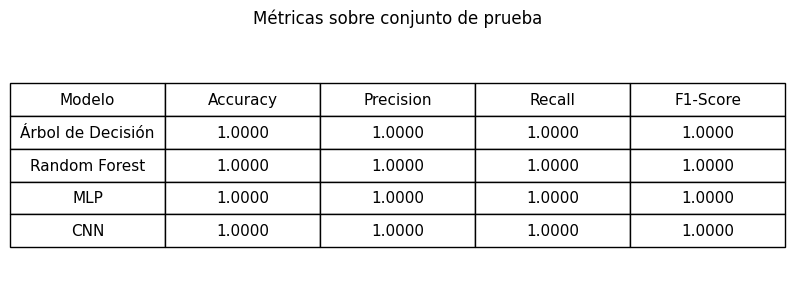

In [35]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')

tabla_data = []
for _, fila in resultados.iterrows():
    tabla_data.append([
        fila['Modelo'],
        f"{fila['Accuracy']:.4f}",
        f"{fila['Precision']:.4f}",
        f"{fila['Recall']:.4f}",
        f"{fila['F1-Score']:.4f}"
    ])

tabla = ax.table(
    cellText  = tabla_data,
    colLabels = ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score'],
    cellLoc   = 'center',
    loc       = 'center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.2, 2.0)
ax.set_title('Métricas sobre conjunto de prueba', fontsize=12, pad=20)
plt.tight_layout()
plt.savefig("tabla_metricas.svg", format='svg', bbox_inches='tight')
plt.show()

**Los cuatro modelos alcanzan métricas perfectas sobre el conjunto de prueba**, lo que impide establecer una diferencia de rendimiento entre ellos dentro de este dataset. La única evaluación que los diferencia es la prueba con imágenes externas reales: al realizar inferencia con la CNN sobre una fotografía real de la letra A con fondo heterogéneo, el modelo predijo D con 35.48% de confianza, con A en segundo lugar con 25.81%. La baja confianza distribuida entre varias clases indica que el modelo no reconoce ningún patrón conocido en la imagen. Esto confirma que **el problema no está en la arquitectura sino en el dataset**. Las imágenes fueron capturadas en condiciones controladas, y **el modelo aprendió a reconocer esas condiciones, no las señas en sí**.

## Grafica de Costo computacional

Dado que las métricas no diferencian los modelos, el *costo computacional es el criterio que permite compararlos*. Se registró el tiempo de
búsqueda de hiperparámetros con GridSearchCV para los modelos clásicos y el tiempo total de entrenamiento para la CNN.

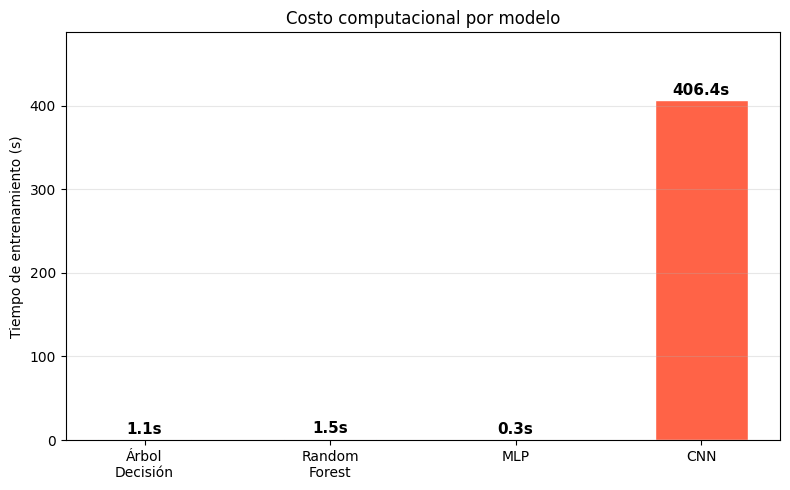

In [37]:
modelos   = ['Árbol\nDecisión', 'Random\nForest', 'MLP', 'CNN']
with open("historia_cnn.json") as f:
    hist_cnn = json.load(f)
tiempos   = [grid_dt.refit_time_, grid_rf.refit_time_, grid_mlp.refit_time_, hist_cnn['tiempo_total_s']]
colores_b = ['steelblue', 'steelblue', 'steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(modelos, tiempos, color=colores_b, edgecolor='white', width=0.5)

ax.set_ylim(0, max(tiempos) * 1.2)  # 20% de espacio encima de la CNN
ax.set_ylabel('Tiempo de entrenamiento (s)')
ax.set_title('Costo computacional por modelo', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

for bar, t in zip(bars, tiempos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{t:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("comparacion_modelos.svg", format='svg')
plt.show()

*El MLP fue se posiciona como el modelo más eficiente con **0.3 segundos** de entrenamiento* sobre los 361 componentes PCA. El árbol de decisión (1.1s) y Random Forest (1.5s) tomaron tiempos comparables y en el mismo orden de magnitud. *La CNN requirió 406.4 segundos (**aproximadamente 7 minutos**) de entrenamiento*, operando sobre imágenes completas sin reducción de dimensionalidad, **sin traducirse en mejor precisión sobre este dataset**.

Los modelos difieren significativamente en complejidad y costo computacional. El árbol de decisión y Random Forest operan sobre reglas explícitas en el espacio PCA y son interpretables. El MLP introdujo no linealidad con una sola capa oculta y convergió en 0.3 segundos. La CNN requirió 406.4 segundos, opera sobre imágenes completas y aprendió representaciones espaciales sin necesidad de PCA. Para este dataset, esa complejidad adicional no se tradujo en mejor precisión, lo que **sugiere que los modelos clásicos son suficientes cuando las condiciones de captura son controladas**.

**Esto ilustra que para conjuntos de datos con baja varianza interna y condiciones de captura controladas, los modelos clásicos sobre representaciones PCA ofrecen el mismo rendimiento que una red profunda a una fracción del costo computacional.**

# Conclusiones

## Resultados del proyecto

Se entrenaron cuatro modelos de aprendizaje supervisado para clasificar las 26 letras del alfabeto ASL a partir de imágenes de manos: Árbol de Decisión, Random Forest, MLP y CNN. Los tres modelos clásicos operaron sobre representaciones `PCA` (95% de varianza explicada, 361 componentes) y fueron ajustados con `GridSearchCV`. La CNN procesó imágenes completas de 128×128 píxeles en escala de grises y fue ajustada mediante búsqueda en cuadrícula manual sobre `learning rate` y `dropout`, dado que ``sklearn`` ``GridSearchCV`` es incompatible con Keras 3.

Los cuatro modelos alcanzaron `accuracy`, `precision`, `recall` y `F1-score` de 1.0 sobre el conjunto de prueba. Este resultado uniforme no refleja diferencias de capacidad entre modelos, sino una limitación estructural del dataset: 200 imágenes por clase capturadas en ráfaga con la misma mano, mismo fondo uniforme y mismos nodos de referencia, generando imágenes casi idénticas distribuidas entre `train`, `val` y `test`. **Las métricas perfectas miden consistencia interna, no generalización**.

La prueba de inferencia con una fotografía real de la letra A en condiciones externas expuso esta limitación: el modelo predijo **D con 35.48%** de confianza, ubicando **A en segundo lugar con 25.81%**. La baja confianza (distribuida entre tres clases sin poder discriminar) indica que el modelo no reconoce ningún patrón conocido en la imagen, no que dude entre opciones similares. **Esto confirma que los modelos aprendieron a reconocer las condiciones del dataset, no la forma de la seña**.

En términos de costo computacional, los modelos presentaron diferencias de dos órdenes de magnitud: el MLP fue el más eficiente con 0.3 segundos, el árbol de decisión y Random Forest tomaron 1.1s y 1.5s respectivamente, y la CNN requirió 406.4 segundos. Para este dataset, esa diferencia de costo no se tradujo en ninguna ventaja de precisión, lo que indica que **la complejidad adicional de la CNN no estaba justificada por los datos disponibles**.

## Lecciones aprendidas

El principal aprendizaje del proyecto no es técnico sino metodológico: **la calidad del dataset determina el techo real del modelo**. Un pipeline de preprocesamiento correcto, una búsqueda de hiperparámetros exhaustiva y una arquitectura bien diseñada no pueden compensar un dataset con baja varianza interna. Las métricas de 1.0 son una señal de alerta, no un logro; en un problema real de 26 clases, `accuracy` perfecta sobre el conjunto de prueba indica que el modelo no fue desafiado durante la evaluación.

La PCA como paso previo a los modelos clásicos resultó efectiva: con 361 componentes se capturó el 95% de la varianza de imágenes de 16,384 dimensiones, reduciendo el espacio de entrada 45 veces su vectorización original sin pérdida de rendimiento. Esto confirma que **la información relevante para distinguir las señas está concentrada en pocos ejes de variación dentro de este dataset controlado**.

## Consideraciones éticas

La Recomendación sobre la Ética de la Inteligencia Artificial de la UNESCO, adoptada en noviembre de 2021 por los 193 estados miembros, establece 10 principios para el desarrollo y uso responsable de sistemas de IA. A continuación se analiza su aplicación en el contexto de un sistema real de reconocimiento de señas ASL:

**1. Proporcionalidad y no causar daño.**
El uso del sistema debe limitarse a su propósito declarado. Un traductor ASL desplegado en producción con un modelo que falla en condiciones reales puede excluir a personas sordas en lugar de asistirlas, causando daño precisamente a la población que busca beneficiar.

**2. Seguridad y protección.**
El modelo debe ser probado exhaustivamente en condiciones reales antes de cualquier despliegue. Los resultados de este proyecto demuestran que un accuracy de 1.0 sobre el dataset no garantiza seguridad de uso en producción.

**3. Privacidad y protección de datos.**
Las imágenes de manos contienen información biométrica. Cualquier sistema que recolecte imágenes de usuarios en tiempo real debe garantizar que esos datos no sean usados para otros fines sin consentimiento explícito.

**4. Gobernanza y colaboración con múltiples partes interesadas.**
El diseño del sistema debe involucrar a la comunidad sorda desde las etapas iniciales, no solo como usuarios finales sino como participantes activos en la definición de requisitos, recolección de datos y evaluación del sistema.

**5. Responsabilidad y rendición de cuentas.**
Debe existir un responsable claro cuando el sistema comete errores. En una aplicación de accesibilidad, un fallo de clasificación puede tener consecuencias directas en la comunicación de una persona sorda.

**6. Transparencia y explicabilidad.**
Los usuarios deben saber cuándo están interactuando con un sistema de IA, qué datos usa y cuáles son sus limitaciones conocidas. Un sistema que predice con 35.48% de confianza una clase incorrecta sin advertir al usuario es potencialmente perjudicial, una confianza baja distribuida entre varias clases es una señal clara de que el modelo está fuera de su dominio, y esa información debe ser visible para quien lo usa.

**7. No discriminación e igualdad**
El dataset utilizado representa una sola mano con un tono de piel específico. Un modelo entrenado así puede funcionar peor para personas con diferentes características físicas, perpetuando sesgos y generando exclusión.

**8. Sostenibilidad ambiental**
El entrenamiento de modelos de deep learning consume recursos computacionales significativos. Se debe evaluar el impacto ambiental del entrenamiento y optar por arquitecturas eficientes cuando sea posible, dependiendo de los datos recopilados.

**9. Derecho a la privacidad y supervisión humana**
Los sistemas de IA no deben reemplazar el juicio humano en decisiones que afectan derechos fundamentales. En contextos críticos de comunicación, debe existir siempre la posibilidad de intervención humana.

**10. Promoción de sociedades justas e inclusivas**
El objetivo final de un sistema de reconocimiento de señas es reducir la brecha de comunicación entre personas oyentes y no oyentes. Para que cumpla ese objetivo, debe ser accesible, preciso y equitativo para toda la diversidad de la comunidad sorda, no solo para las condiciones controladas del laboratorio.

## Trabajo futuro

Para mejorar la capacidad de generalización de los modelos se propone:

- Reemplazar el dataset actual por uno más diverso, con distintas manos, tonos de piel, fondos, ángulos e iluminaciones, que represente condiciones reales de uso.
- Incorporar los 21 nodos de referencia de la mano detectados como características adicionales, desacoplando el modelo del fondo y la iluminación.
- Aplicar data augmentation más agresivo durante el entrenamiento: cambios de iluminación, fondos sintéticos heterogéneos y variaciones de tono de piel.
- Evaluar los modelos con un conjunto de prueba externo recolectado en condiciones reales, separado completamente del dataset de entrenamiento.
- Evaluar arquitecturas preentrenadas mediante transfer learning (VGG16, ResNet50) que ya aprendieron representaciones visuales robustas sobre millones de imágenes. Sin embargo, estos modelos fueron preentrenados en ImageNet, un dataset de objetos generales, no de manos ni señas, por lo que requerirían `fine-tuning` para adaptar sus representaciones al dominio específico de ASL y evitar que características aprendidas de contextos no relacionados interfieran con la clasificación.